Created 4/23/2022

new model comparisons because the other one was becoming too crowded.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()
from decodedoutputdefs import Precision, training_curve_indv, training_curve_average #class with the compiled definitions

In [4]:
#extra definitions 

def modelerr(base, plot = True, title = '', additional_title = ''): 
    files = os.listdir(base)
    full_files = [base+f for f in files if 'Base.csv' in f]
    print(len(full_files))
    p = Precision()
    err = p.mult_models(full_files)
    #print(len(err))

    if plot: 
        plt.figure()
        plt.hist(err, bins = 50)
        if "StimRange0to45" in base:
            model_name = base.split('/')[1]+' StimDist Max 45'
        else:
            model_name = base.split('/')[1] 
        if 'decodedrew' in base:
            rewardfun = 'Decoded'
        else: 
            rewardfun = 'Unit Difference'
        if 'contexp' in base:
            rewardtype = 'Continuous Exponential'
        elif 'RewThresh' in base:
            rewardtype = 'Binary'
        else:
            rewardtype = 'Continuous Linear'
        if 'NoIgnore' in base:
            ignore = ', No Ignore Trials'
        else:
            ignore = ''
        if title == '':
            title = model_name + ', Reward Function: ' + rewardtype +', ' +rewardfun +' '+ ignore +' '+additional_title
        plt.title(title)
        abserr = np.mean(np.abs(err))
        legend = 'Average Absolute Error = {:.2f}'.format(abserr)
        #mse = np.sqrt(np.mean(err**2))
        #legend = 'mse = {:.2f}'.format(mse)
        plt.legend([legend])
        plt.show()
    
    return err


In [48]:

def overlayhist(base, base2, task,experiment, errchunk = [], err = [], title = '', savefig = False, savefile = '', ABE = False, nonresponse = 'guess'):

    
    if len(errchunk) == 0:
        base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
        files = os.listdir(base_chunk)
        files = [f for f in files if 'Base.csv' in f]
        full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
        full_files = [f for f in full_files if 'TrialLog' not in f]
        print(len(full_files))
        p = Precision()
        errchunk = p.mult_models(full_files, nonresponse = nonresponse)
        
        if ABE:
            total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
        else:
            total_mean_chunk, std_chunk = 0,0
    
    if len(err) == 0:
        if task == "2":
            base_nochunk = base + "sir2_new/"+base2+experiment
        else:
            base_nochunk = base+ "sir"+task+"/"+base2+experiment
        files = os.listdir(base_nochunk)
        files = [f for f in files if 'Base.csv' in f]
        full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
        full_files = [f for f in full_files if 'TrialLog' not in f]
        print(len(full_files))
        p = Precision()
        err = p.mult_models(full_files, nonresponse = nonresponse)
        if ABE:
            total_mean_nochunk, std_nochunk = geterror(base_nochunk, full_files)
        else:
            total_mean_nochunk, std_nochunk = 0,0

#     plot1 = plt.hist(errchunk,bins = np.linspace(-180,180,45), alpha = 0.4)
#     plot2 = plt.hist(err,bins = np.linspace(-180,180,45), alpha = 0.4, color = "yellow")

#     # calc middle of bin and width of bin
#     ax = [(plot1[1][x]+plot1[1][x+1])/2 for x in range(len(plot1[1])-1)] 
#     diff = [_plot1 - _plot2 for _plot1, _plot2 in zip(plot1[0], plot2[0])]
#     plt.bar(ax, diff,width = 6, color = "red")
#     plt.legend(['Chunk', "No Chunk", "Chunk - No Chunk"])

    overlay_hist2(errchunk,err)
    #CB = chunkingbenefit(ax,diff,len(err))
    #plt.title(title+" ,CB: {:.4f}".format(CB))
    if savefig: 
        plt.savefig(savefile)    
    plt.show()
    
    ax = []
    df = []
    CB = []
    
    return errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk



def chunkingbenefit(ax, diff, numtrials):
    npax = np.array(ax)
    npdiff = np.array(diff)
    #density (in the diff histogram) in middle - density outside 
    CB = np.sum(npdiff[np.logical_and(npax<30,npax>-30)])-np.sum(npdiff[np.logical_or(npax>30, npax<-30)]) 
    CB_norm = CB/numtrials
    return CB_norm 


def geterror(base, full_files = []):
    if len(full_files) == 0:
        full_files = getfiles(base)
    num_models = len(full_files)
    p = Precision()
    L1_means = np.zeros(num_models)
    L1_vars = np.zeros(num_models)
    for f in range(len(full_files)):
        #import pdb; pdb.set_trace()
        err_model = p.mult_models([full_files[f]])
        L1 = np.abs(err_model)
        L1_means[f]=np.mean(L1)
        L1_vars[f] = np.var(L1)
    #mse = np.sqrt(np.mean(err**2)) 
    total_mean = np.mean(L1_means)
    total_var = np.mean(L1_vars)/num_models
    #err = p.mult_models(full_files)
    return total_mean, np.sqrt(total_var)

def run_all(base, base2, experiment):
    task = "4"
    errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

    task = "3"
    errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

    task = "2"
    errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)
    
def overlay_hist2(errchunk,err,bins = 45, title = '', xmin = -180, xmax = 180, plot_diff = True, redwidth = 6, leg = [], density = False):
    plot1 = plt.hist(errchunk,bins = np.linspace(xmin,xmax,bins), alpha = 0.4, label='Chunk', density = density)
    plot2 = plt.hist(err,bins = np.linspace(xmin,xmax,bins), alpha = 0.4, color = "yellow", label='No Chunk', density = density)
    # calc middle of bin and width of bin
    if plot_diff:
        ax = [(plot1[1][x]+plot1[1][x+1])/2 for x in range(len(plot1[1])-1)] 
        diff = [_plot1 - _plot2 for _plot1, _plot2 in zip(plot1[0], plot2[0])]
        plt.plot(ax,diff, label='Chunk - No Chunk')
        #plt.bar(ax, diff,width = redwidth, color = "red", edgecolor = "red")
        plt.axhline(y = 0.0, color = "black", linewidth = 0.5, label='curve4')
        plt.axvline(x = 0.0, color = "black", linewidth = 0.5, label='curve5')
        if len(leg) != 0:
            plt.legend(leg)
        else:
            plt.legend(['Chunk', "No Chunk", "Chunk - No Chunk",'',''])
            handles, labels = plt.gca().get_legend_handles_labels()

            #specify order of items in legend
            order = [3,4,0]

            #add legend to plot
            plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
    else:
        if len(leg) !=0:
            plt.legend(leg)
        else:
            plt.legend(['Chunk', "No Chunk"])
            
    plt.title(title)
    plt.show()

80
80


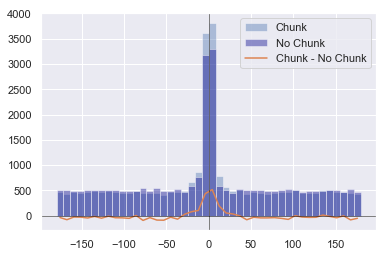

NameError: name 'diff' is not defined

In [44]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

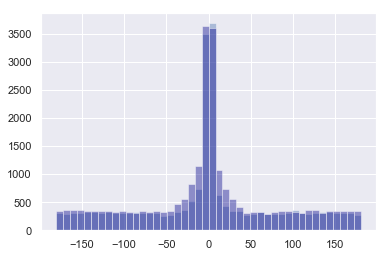

In [37]:
plot1 = plt.hist(errchunk,bins = np.linspace(-180,180,45), alpha = 0.4, label='Chunk')
plot1 = plt.hist(err,bins = np.linspace(-180,180,45), alpha = 0.4, label='No Chunk', color = 'darkblue')

80
80


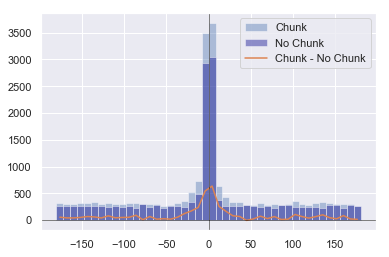

NameError: name 'ax' is not defined

In [41]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, nonresponse = 'remove')

80
80


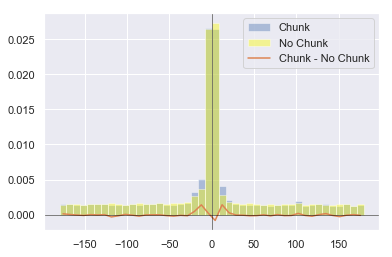

NameError: name 'ax' is not defined

In [25]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, nonresponse = 'remove')

80
80


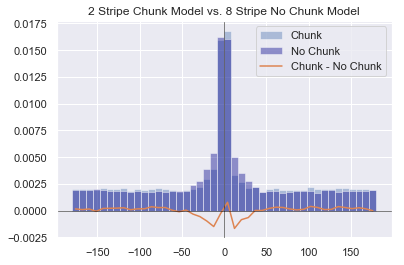

In [47]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if 'Base.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files, nonresponse = 'guess')

base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
base_nochunk = base+ "sir"+task+"/"+base2+experiment
files = os.listdir(base_nochunk)
files = [f for f in files if 'Base.csv' in f]
full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
err = p.mult_models(full_files, nonresponse = 'guess')

overlay_hist2(errchunk,err, title = '2 Stripe Chunk Model vs. 8 Stripe No Chunk Model', density = True)

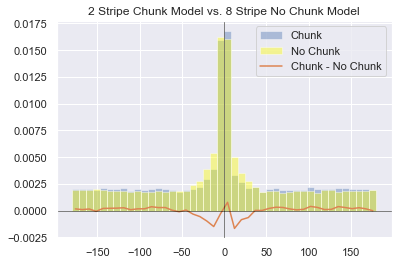

In [49]:
overlay_hist2(errchunk,err, title = '2 Stripe Chunk Model vs. 8 Stripe No Chunk Model', density = True)

In [10]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
base_nochunk = base+ "sir"+task+"/"+base2+experiment
files = os.listdir(base_nochunk)
files = [f for f in files if 'Base.csv' in f]
full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
err = p.mult_models(full_files, nonresponse = 'remove')

80


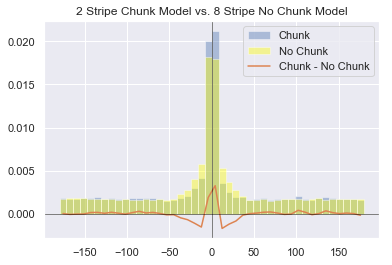

In [23]:
overlay_hist2(errchunk,err, title = '2 Stripe Chunk Model vs. 8 Stripe No Chunk Model')

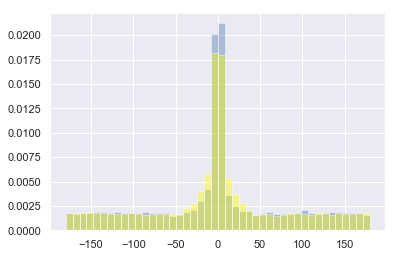

In [14]:
plt.hist(errchunk,bins = np.linspace(-180,180,45), alpha = 0.4, density = True)
plt.hist(err,bins = np.linspace(-180,180,45), alpha = 0.4, color = 'yellow', density = True)
plt.show()

In [90]:
p.num_nonresponse

3478

In [91]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if 'Base.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
p.num_nonresponse

80


6701

In [86]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if 'Base.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)

base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
base_nochunk = base+ "sir"+task+"/"+base2+experiment
files = os.listdir(base_nochunk)
files = [f for f in files if 'Base.csv' in f]
full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
err = p.mult_models(full_files)

Y:/sir4/results/Ring/8Stripe/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/
80


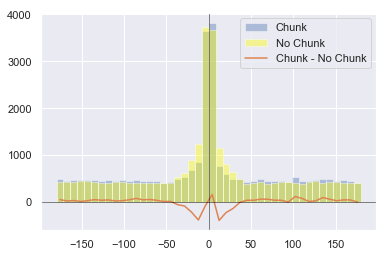

In [87]:
overlay_hist2(errchunk,err)

80
80


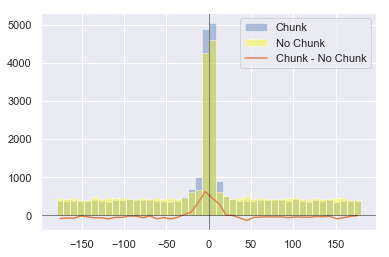

In [79]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/testint/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

80
80


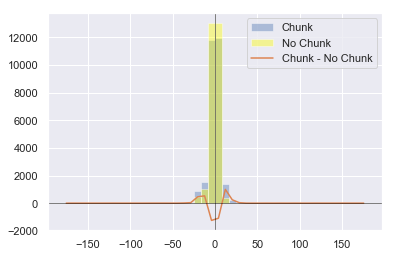

In [80]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

80
80


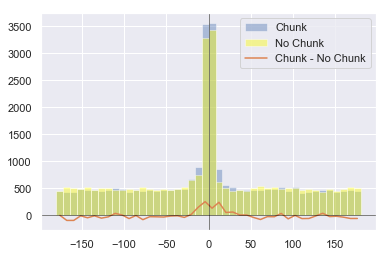

In [81]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/testint/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

80
80


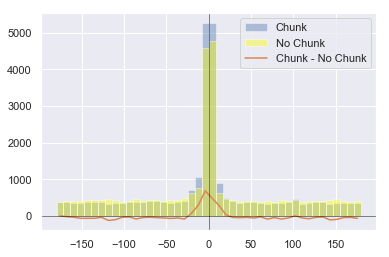

In [73]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

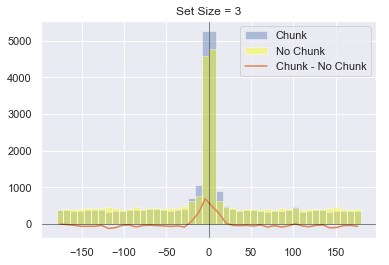

In [75]:
overlay_hist2(errchunk,err, title = 'Set Size = 3')

80
80


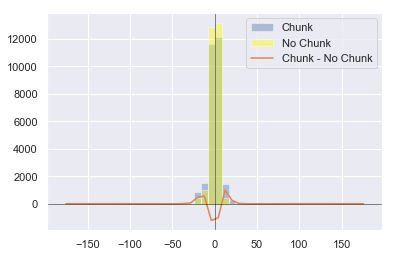

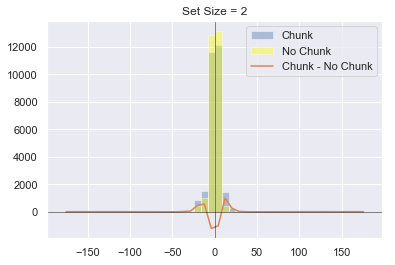

In [76]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)
overlay_hist2(errchunk,err, title = 'Set Size = 2')

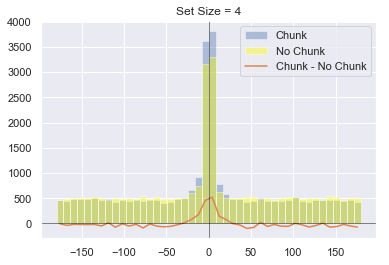

In [67]:
overlay_hist2(errchunk,err, title = 'Set Size = 4')

80
80


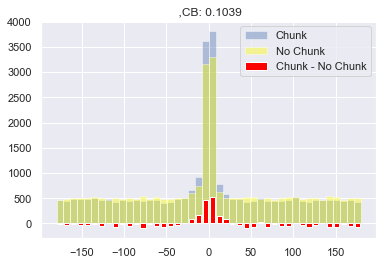

In [15]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

36
36


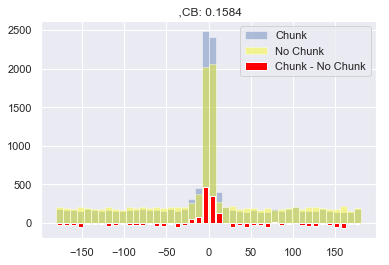

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

36
36


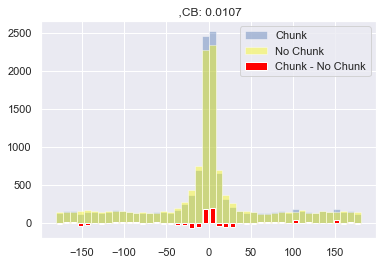

In [12]:
base = "Y:/"
base2 = "results/Ring/32Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

36
36


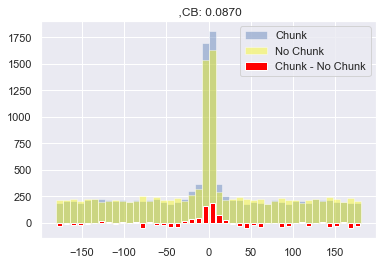

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

36
36


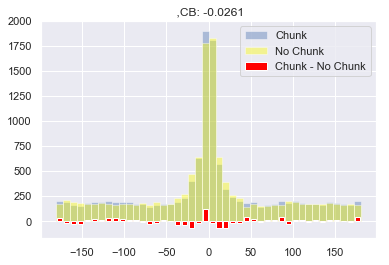

In [4]:
base = "Y:/"
base2 = "results/Ring/32Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

80
80


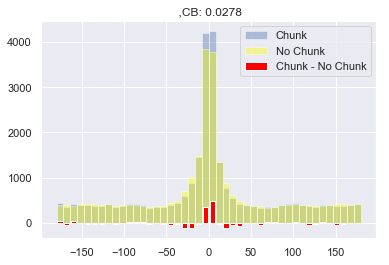

In [6]:
base = "Y:/"
base2 = "results/Ring/16Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


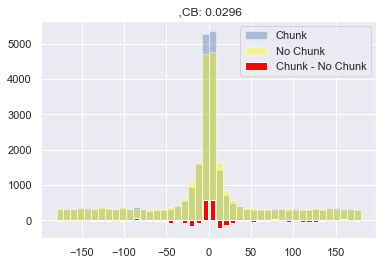

In [7]:
base = "Y:/"
base2 = "results/Ring/16Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


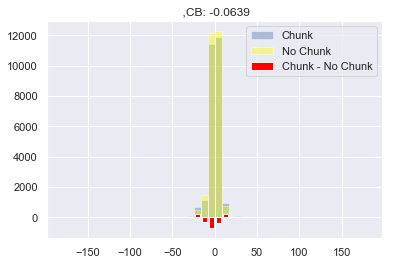

In [8]:
base = "Y:/"
base2 = "results/Ring/16Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


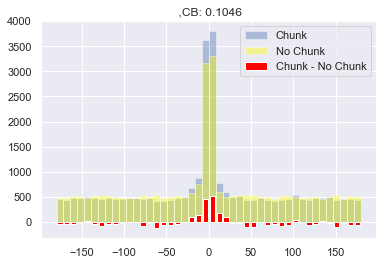

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


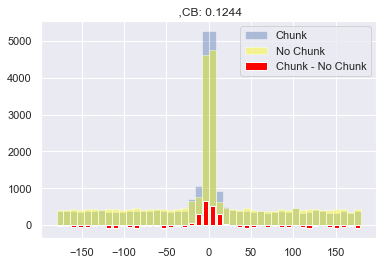

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
task = "3"
errchunk3, err3, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


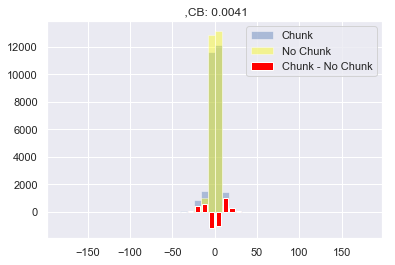

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "2"
errchunk2, err2, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


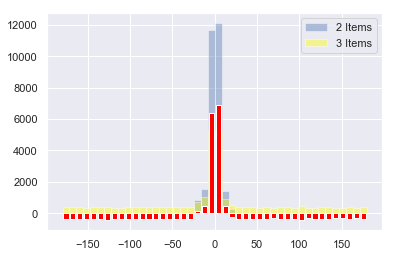

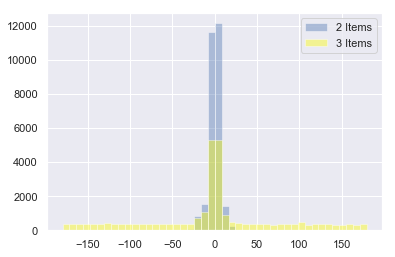

In [20]:
overlay_hist2(errchunk2,errchunk3, leg = ['2 Items', '3 Items'])
overlay_hist2(errchunk2,errchunk3, leg = ['2 Items', '3 Items'], plot_diff = False)

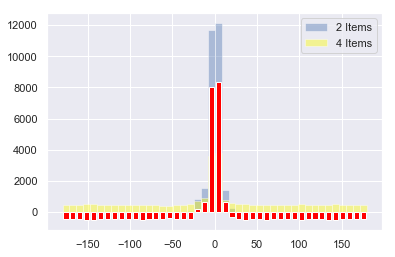

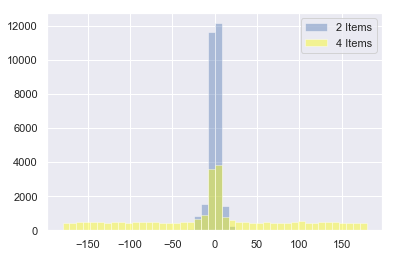

In [21]:
overlay_hist2(errchunk2,errchunk, leg = ['2 Items', '4 Items'])
overlay_hist2(errchunk2,errchunk, leg = ['2 Items', '4 Items'], plot_diff = False)

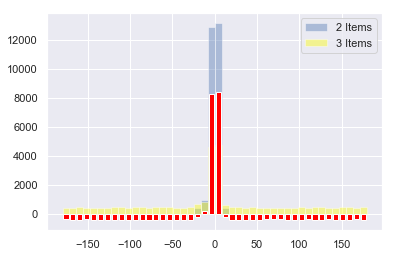

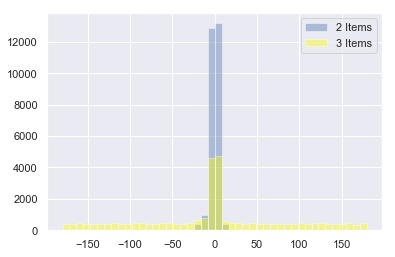

In [22]:
overlay_hist2(err2,err3, leg = ['2 Items', '3 Items'])
overlay_hist2(err2,err3, leg = ['2 Items', '3 Items'], plot_diff = False)

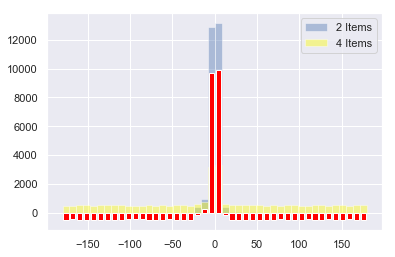

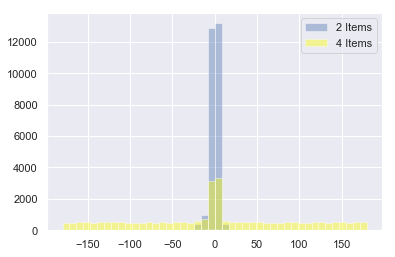

In [23]:
overlay_hist2(err2,err, leg = ['2 Items', '4 Items'])
overlay_hist2(err2,err, leg = ['2 Items', '4 Items'], plot_diff = False)

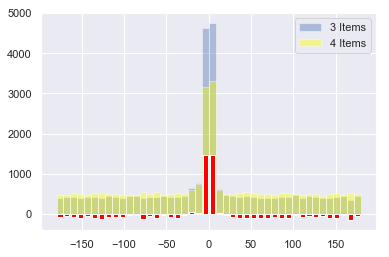

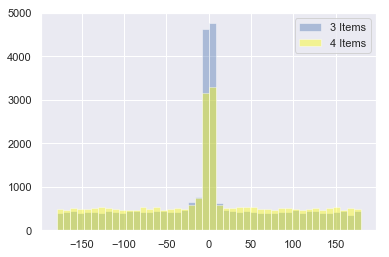

In [24]:
overlay_hist2(err3,err, leg = ['3 Items', '4 Items'])
overlay_hist2(err3,err, leg = ['3 Items', '4 Items'], plot_diff = False)

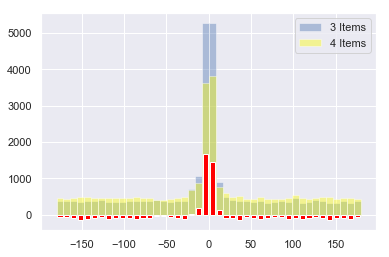

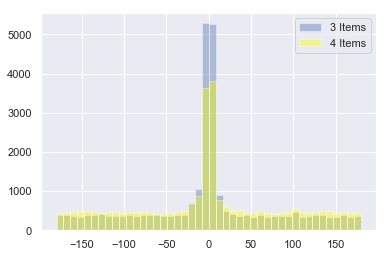

In [25]:
overlay_hist2(errchunk3,errchunk, leg = ['3 Items', '4 Items'])
overlay_hist2(errchunk3,errchunk, leg = ['3 Items', '4 Items'], plot_diff = False)

80
80


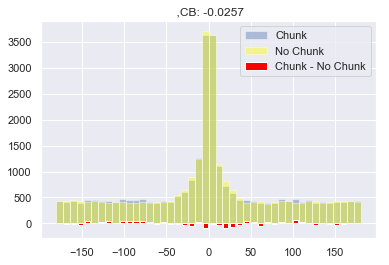

In [4]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


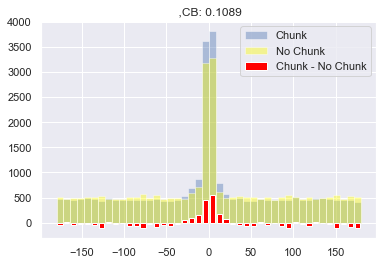

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


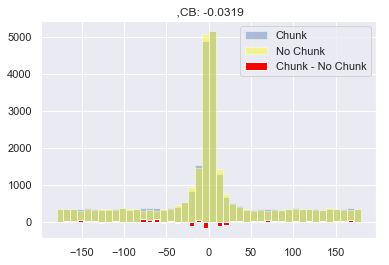

In [7]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


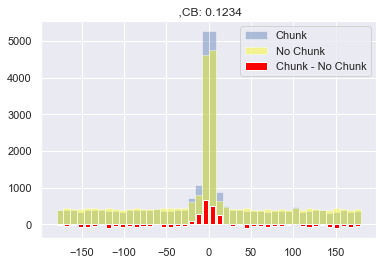

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/copy/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


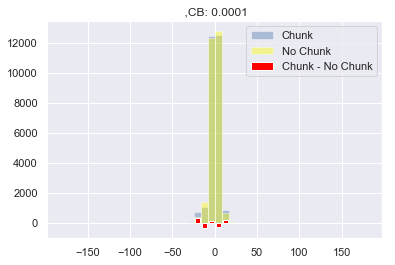

In [10]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


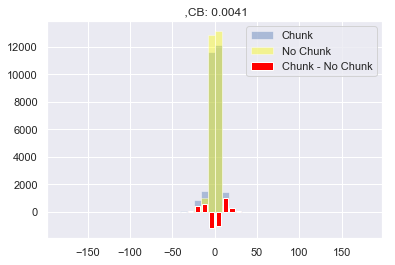

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


64
64


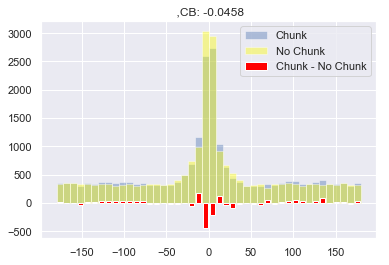

In [7]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/halfchunknochunk/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


64
64


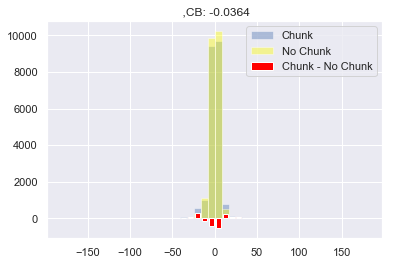

In [8]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/halfchunknochunk/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


64
64


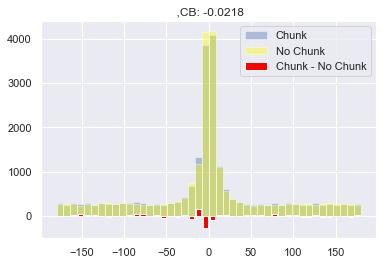

In [5]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/halfchunknochunk/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


64
64


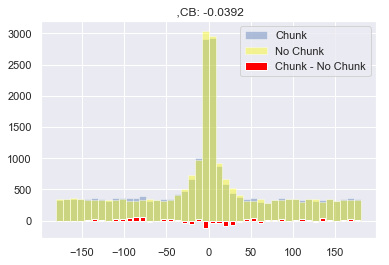

In [4]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


64
64


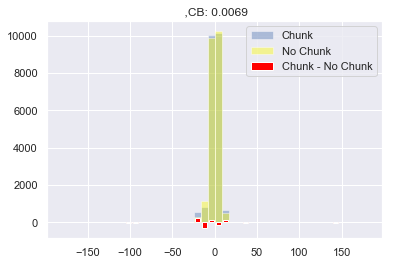

In [5]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


64
64


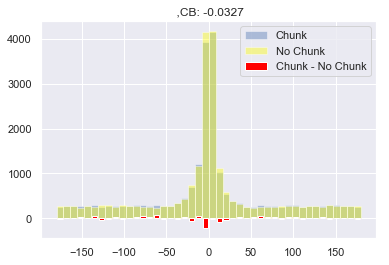

In [6]:
base = "Y:/"
base2 = "results/Ring/8Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80


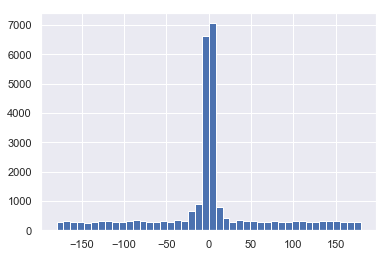

In [22]:
task = '2'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip4/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
plt.hist(errchunk, bins = np.linspace(-180,180,45))
plt.show()

80


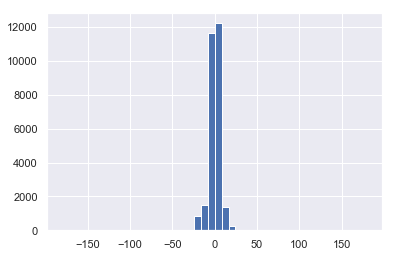

In [23]:
task = '2'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst16/Dip16/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
plt.hist(errchunk, bins = np.linspace(-180,180,45))
plt.show()

In [5]:
task = '2'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)

80


80


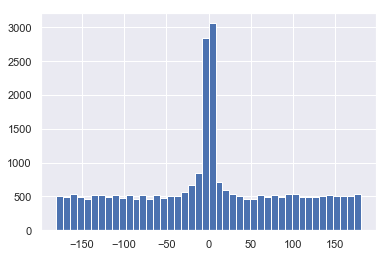

In [26]:
task = '3'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
plt.hist(errchunk, bins = np.linspace(-180,180,45))
plt.show()

80


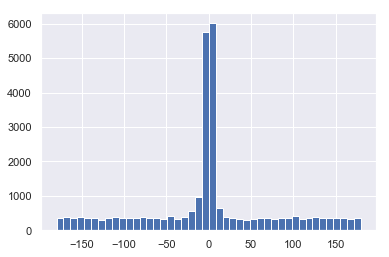

In [27]:
task = '3'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip6/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
plt.hist(errchunk, bins = np.linspace(-180,180,45))
plt.show()

80


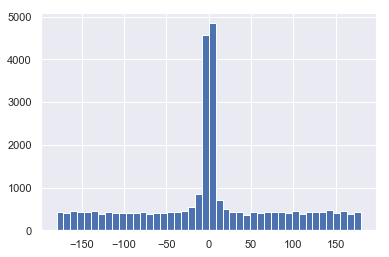

In [28]:
task = '4'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst14/Dip10/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
plt.hist(errchunk, bins = np.linspace(-180,180,45))
plt.show()

80


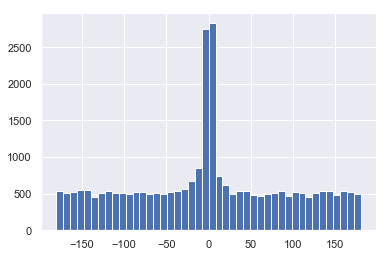

In [29]:
task = '4'
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst8/Dip14/"
base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
total_mean_chunk, std_chunk = geterror(base_chunk, full_files)
plt.hist(errchunk, bins = np.linspace(-180,180,45))
plt.show()

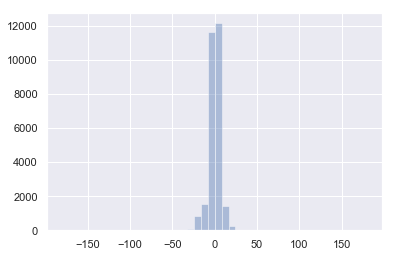

In [10]:
plt.hist(errchunk, bins = np.linspace(-180,180,45), alpha = 0.4)
plt.show()

80
80


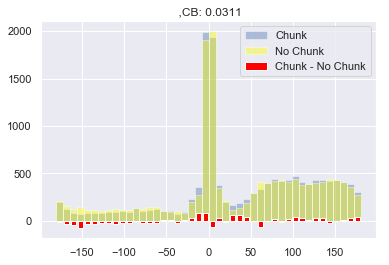

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/try/chunktrials/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


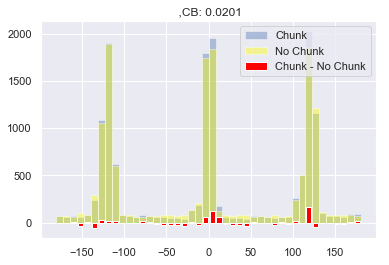

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/try/uniformtrials/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


160
160


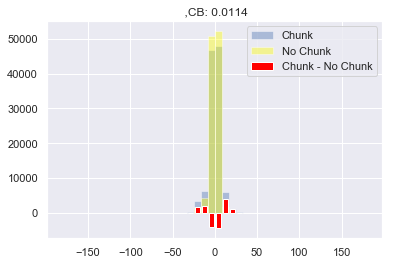

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


160
160


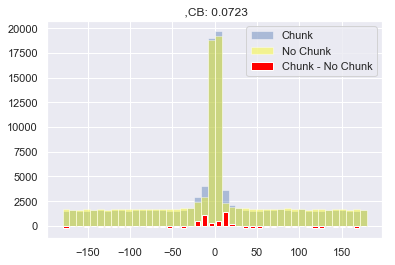

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


160
160


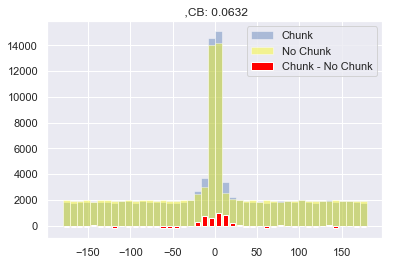

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moremodels/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


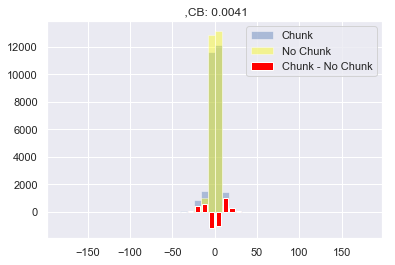

80
80


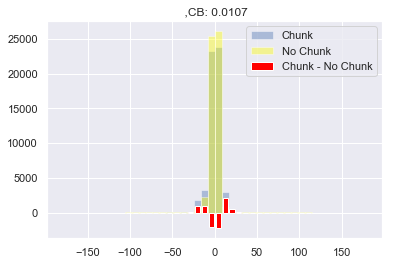

In [4]:
#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


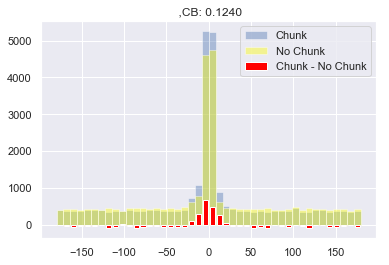

In [4]:
#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrate06/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


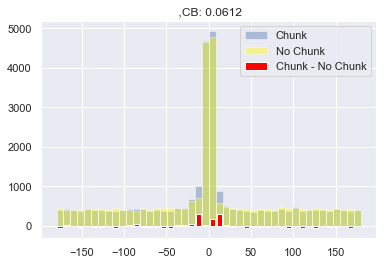

80
80


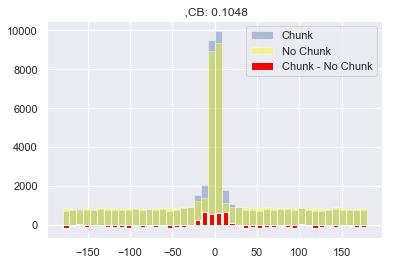

In [5]:
#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


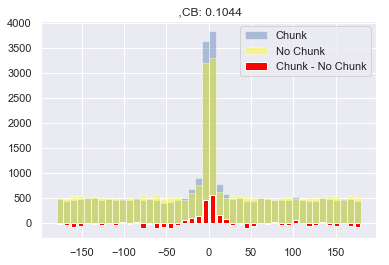

80
80


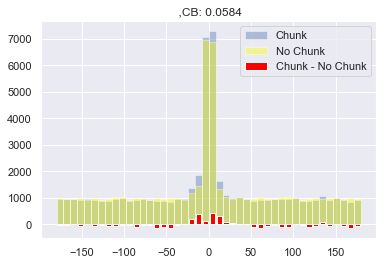

In [6]:
#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/moretesttrials/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


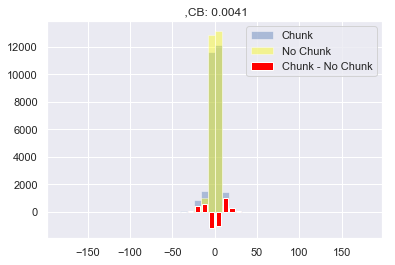

In [4]:
#base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


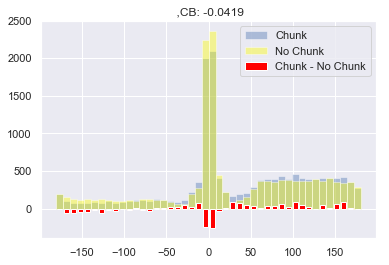

In [21]:
#need o run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/chunktrials/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


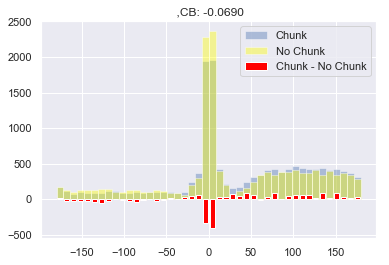

In [22]:
#need to run in the morn
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/uniformtrials/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


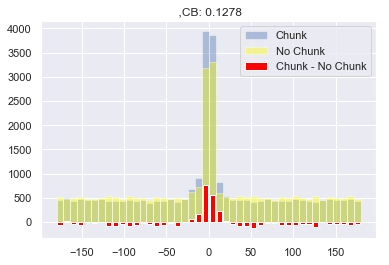

In [14]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


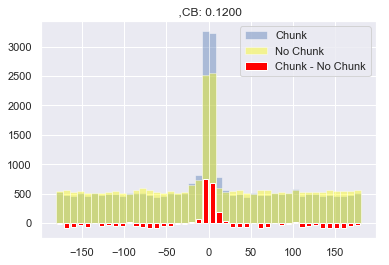

In [15]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/TestNoGo125/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


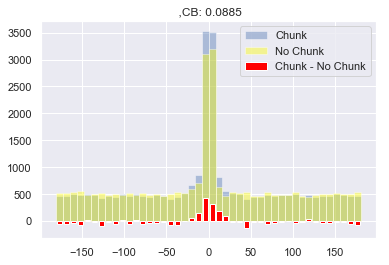

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate03/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


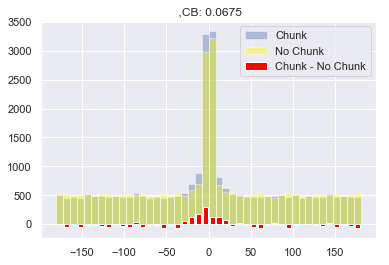

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate02/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


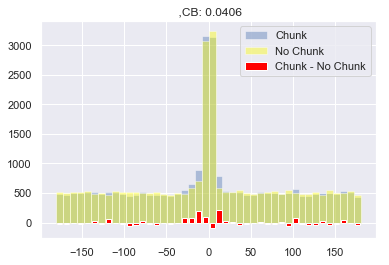

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate01/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


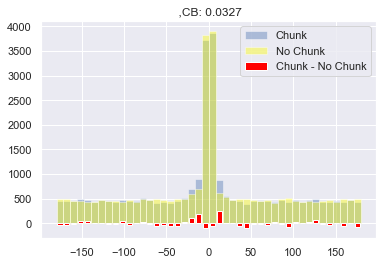

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


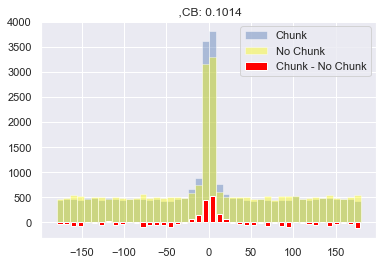

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


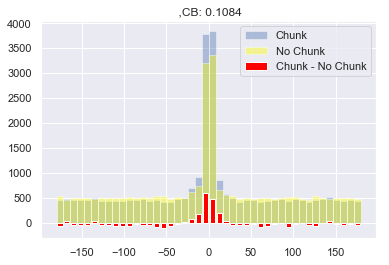

80
80


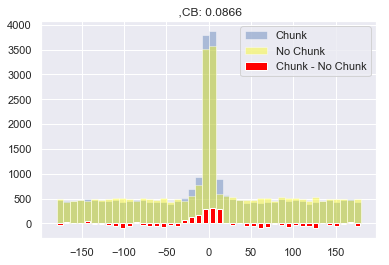

80
80


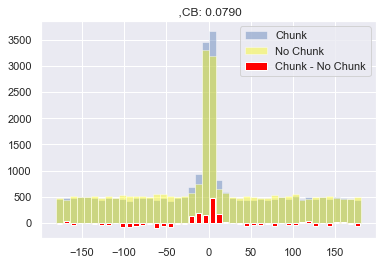

80
80


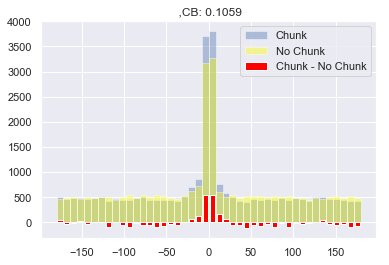

80
80


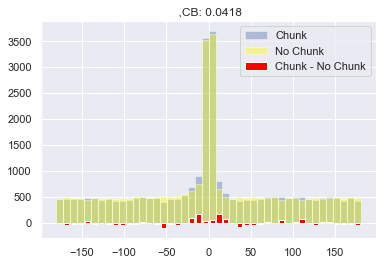

In [10]:

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate05/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate07/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate08/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate09/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate1/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


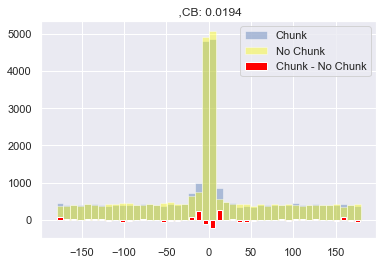

80
80


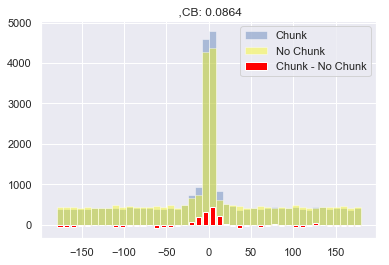

80
80


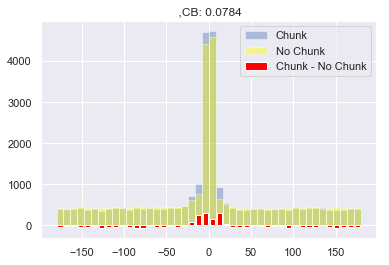

80
80


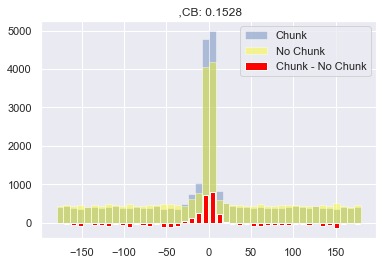

80
80


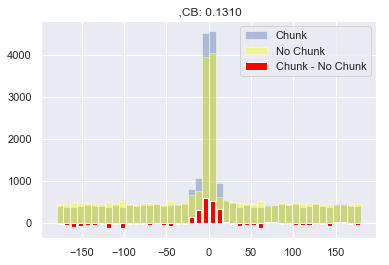

In [12]:

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate05/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate07/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate08/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate09/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate1/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


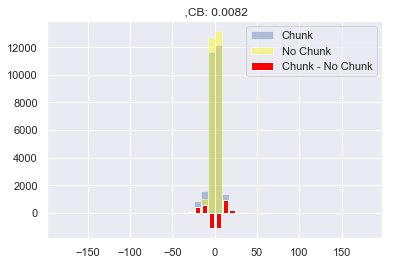

80
80


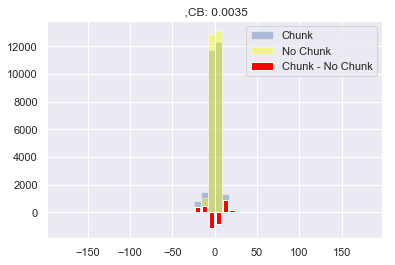

80
80


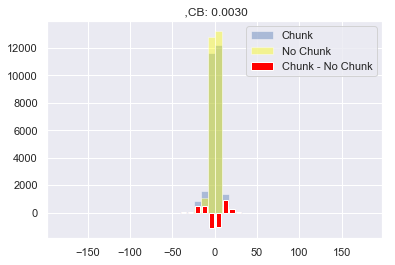

80
80


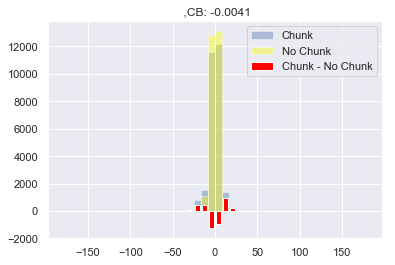

80
80


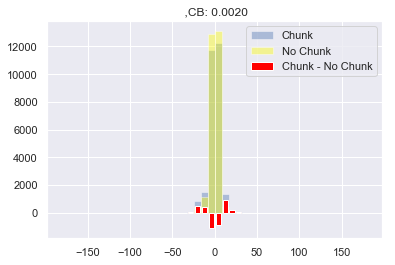

In [13]:

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate05/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate07/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate08/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate09/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate1/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


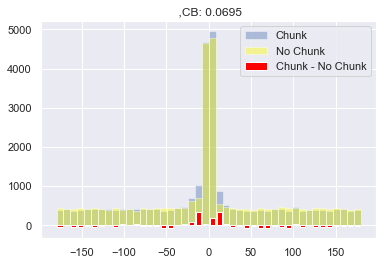

80
80


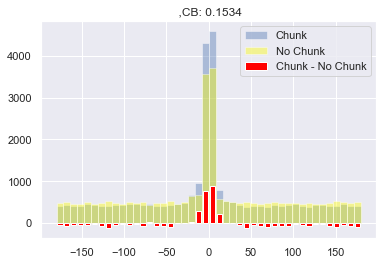

80
80


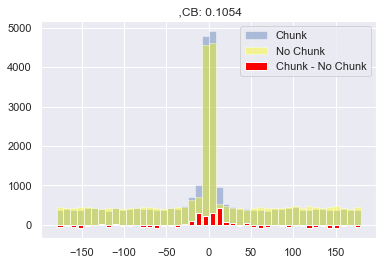

80
80


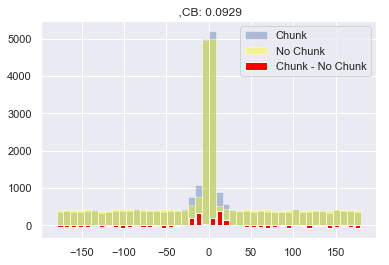

80
80


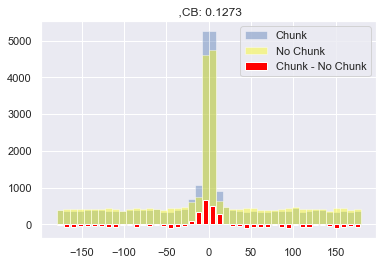

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate01/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate02/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate03/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


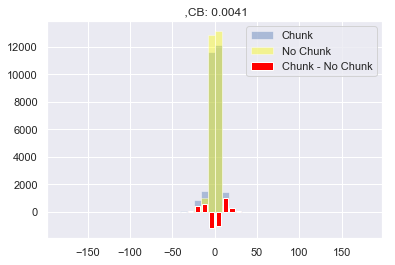

80
80


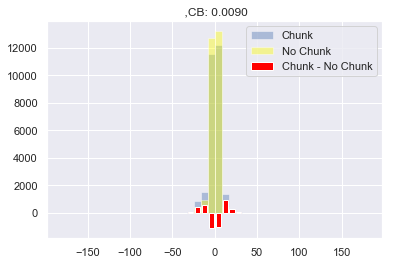

80
80


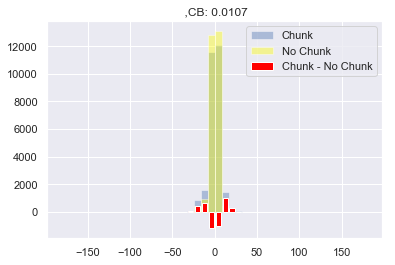

80
80


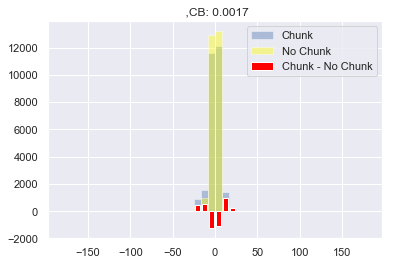

80
80


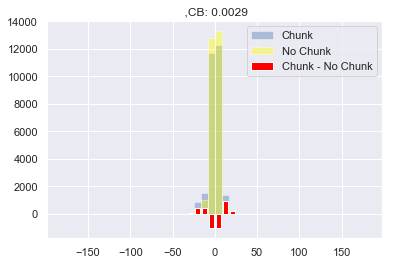

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst10/Dip10/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate01/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate02/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate03/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLocNoHidden/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Lrate06/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


In [ ]:
#maybe stimloc does help? add the stimloc back in for sir3 and sir4? 

80
80


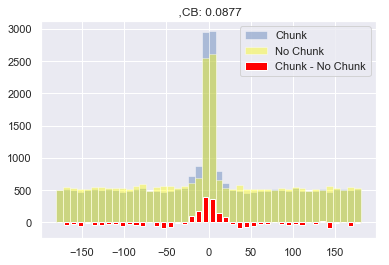

In [47]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fixedcode/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


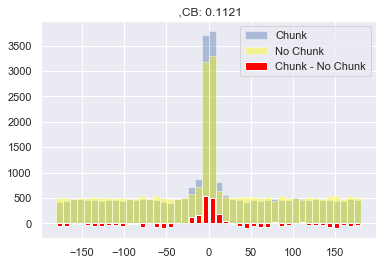

In [48]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fixedcode/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


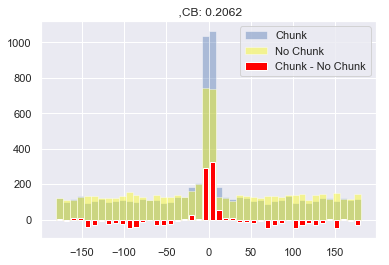

In [43]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fixedcode/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


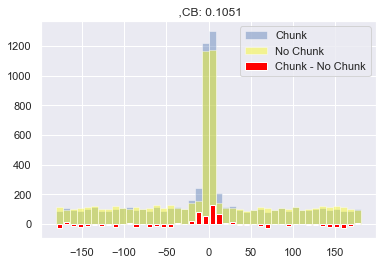

In [44]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fixedcode/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


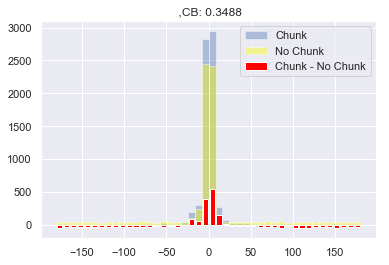

In [45]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fixedcode/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


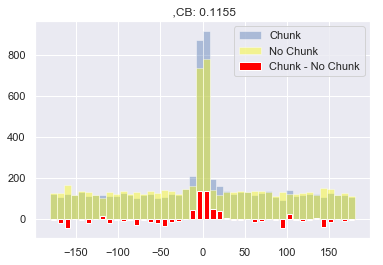

In [46]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fixedcode/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


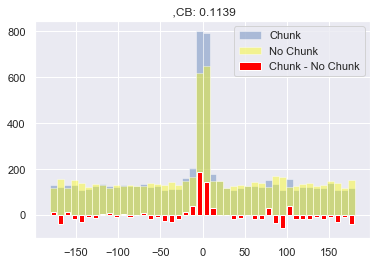

In [38]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/orgcode/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


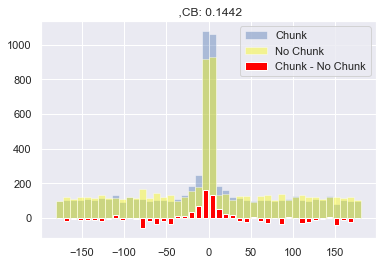

In [39]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/orgcode/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


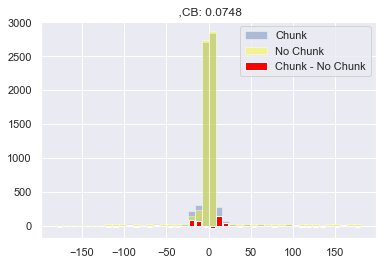

In [40]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/orgcode/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


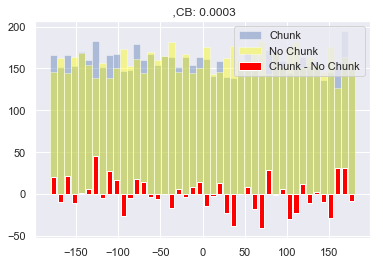

In [32]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/NoHidden/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


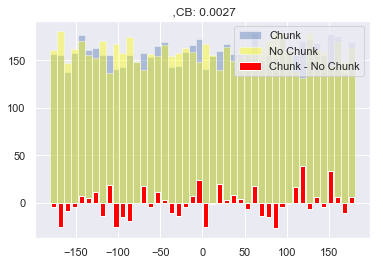

In [33]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/NoHidden/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20
20


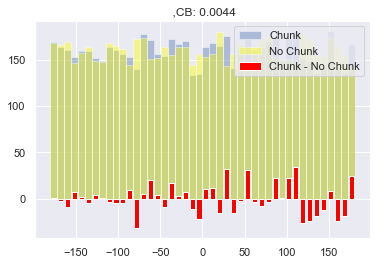

In [25]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/NoHidden/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


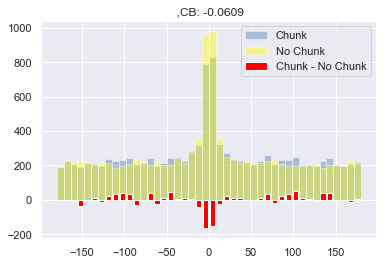

In [26]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/clearallstripes/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


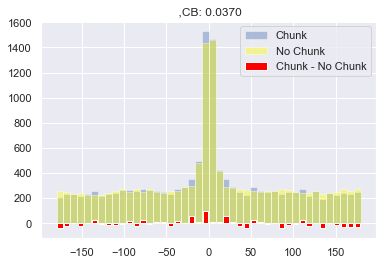

In [27]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/clearallstripes/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


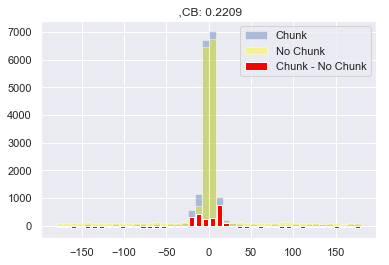

In [17]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/clearallstripes/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


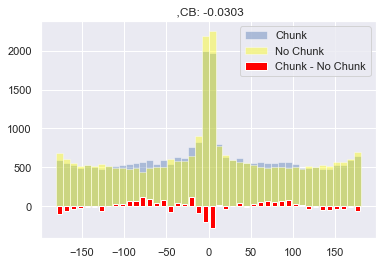

In [18]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


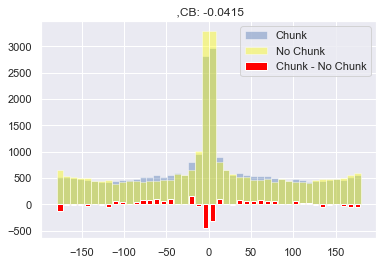

In [19]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


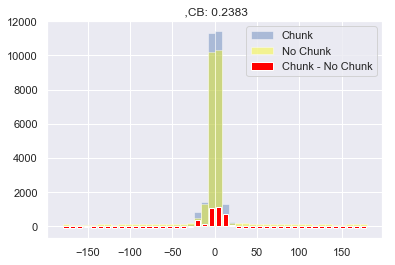

In [20]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/cont/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


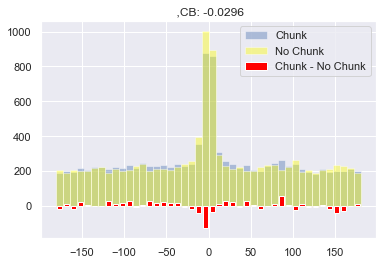

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/clearallstripes/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


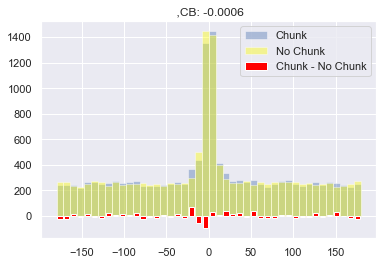

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/clearallstripes/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


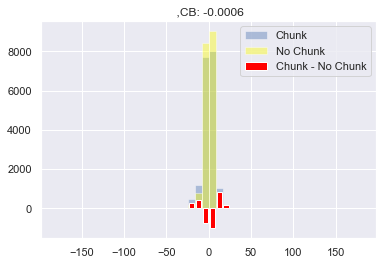

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/clearallstripes/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


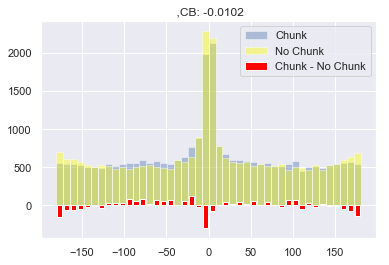

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


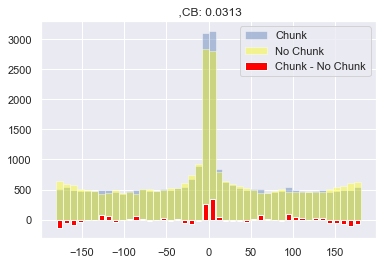

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


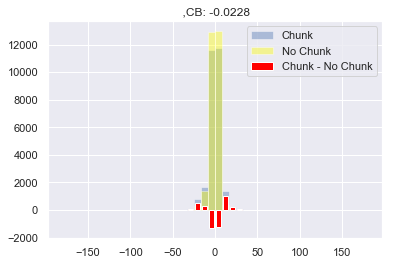

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


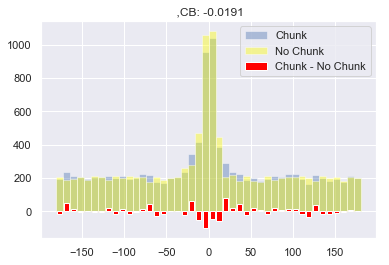

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/OutClearMaint/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


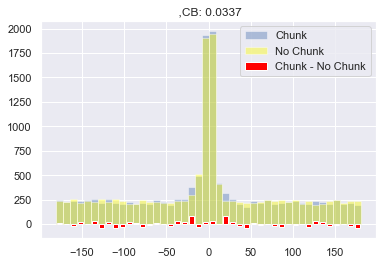

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/OutClearMaint/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


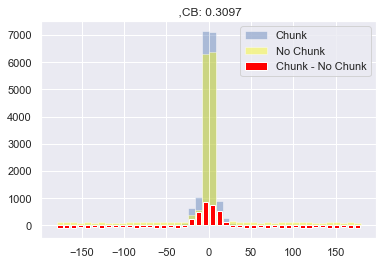

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/resetstim/OutClearMaint/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80


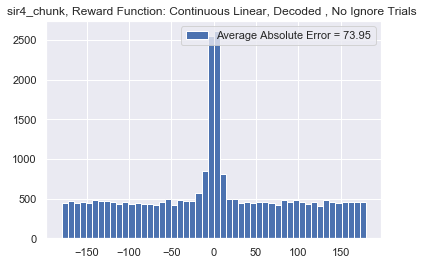

80


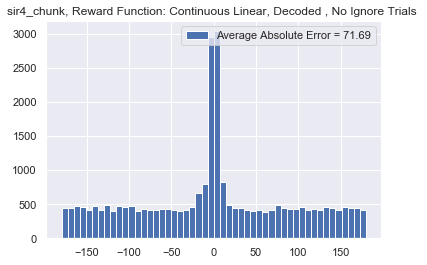

80


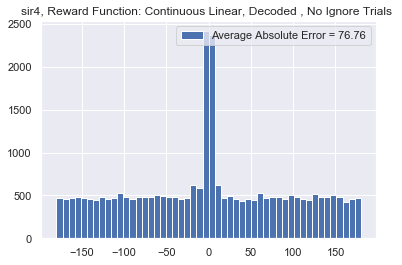

80


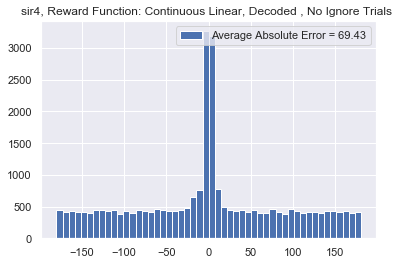

In [38]:
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base)

base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base)

base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base)

80


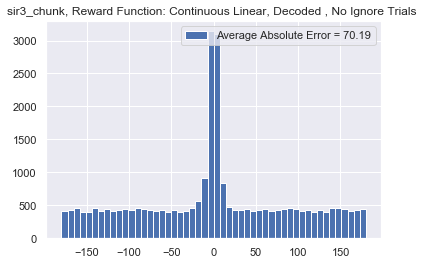

80


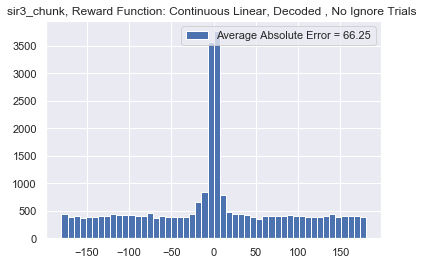

80


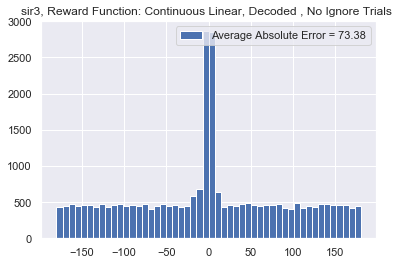

80


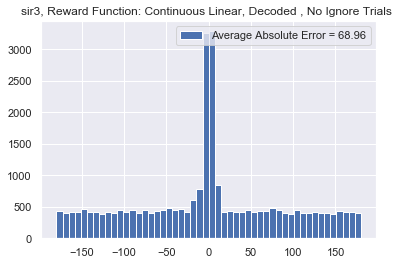

In [39]:
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base)

base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base)

base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base)

80


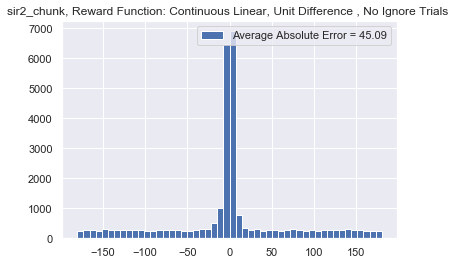

80


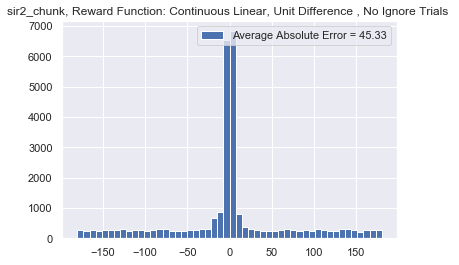

80


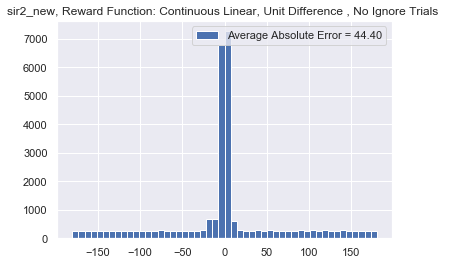

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Y:/sir2_new/results/Ring/2Stripe/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/'

In [37]:
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base)

base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base)

base = "Y:/sir2_new/results/Ring/2Stripe/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base)
base = "Y:/sir2_new/results/Ring/2Stripe/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base)

80


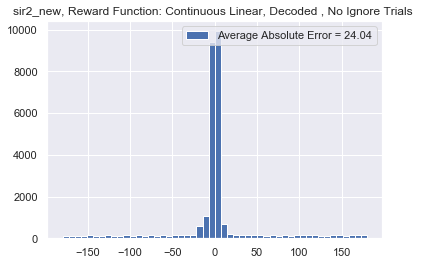

80


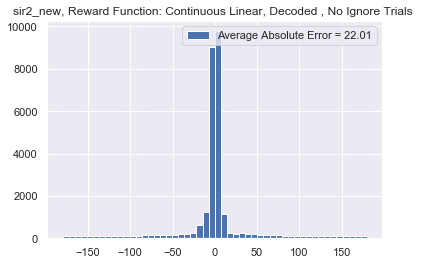

In [36]:
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base)

base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base)

base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base)

80
80


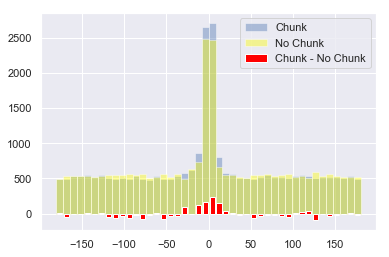

In [25]:
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


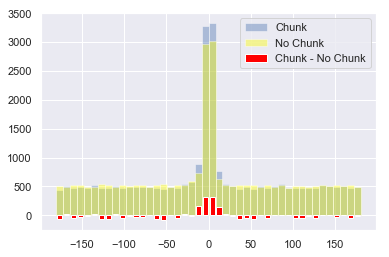

In [26]:
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


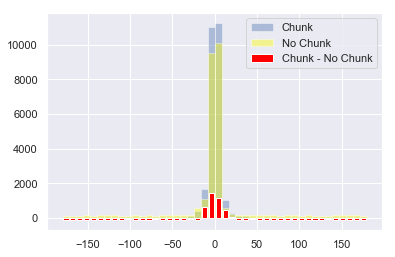

In [27]:
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


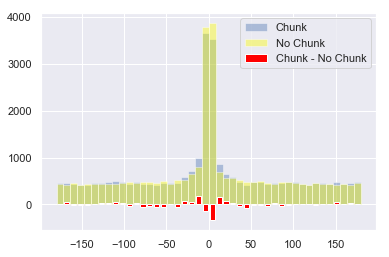

In [29]:
#unit difference
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir4/results/Ring/2Stripe/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


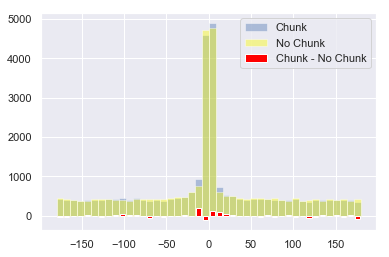

In [30]:
#unit difference
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir3/results/Ring/2Stripe/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


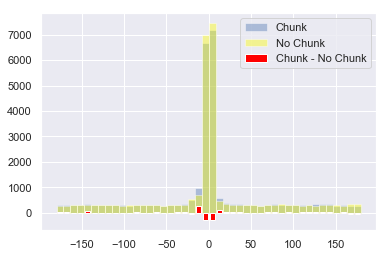

In [31]:
#unit difference
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lowinhib/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir2_new/results/Ring/2Stripe/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

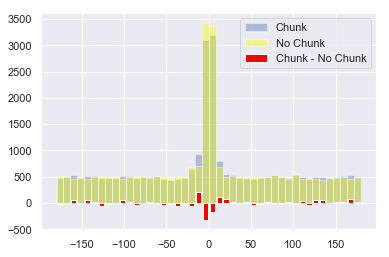

In [13]:
base = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


<Figure size 432x288 with 0 Axes>

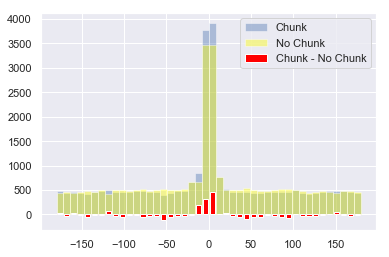

In [19]:
plt.figure()
base = "Y:/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base, plot = False)
plt.figure()
overlay_hist2(errchunk, err)

80
80


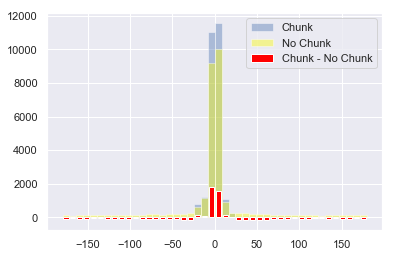

In [20]:
base = "Y:/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
errchunk = modelerr(base,plot = False)
base = "Y:/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/highinhib/"
err = modelerr(base, plot = False)
overlay_hist2(errchunk, err)

80
80


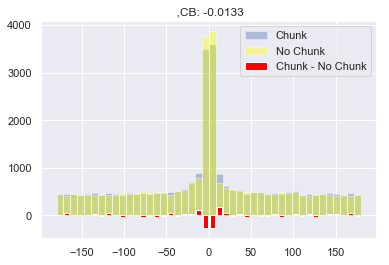

In [22]:
#unitdifference
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


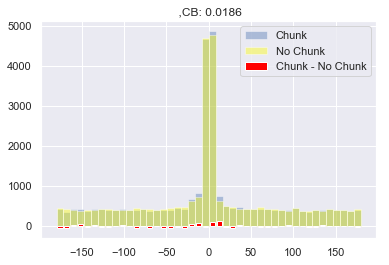

In [23]:
#unitdifference
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


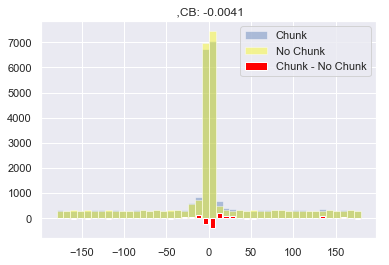

In [24]:
#unitdifference
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


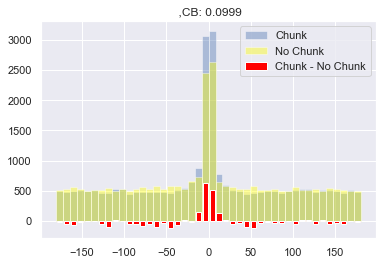

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


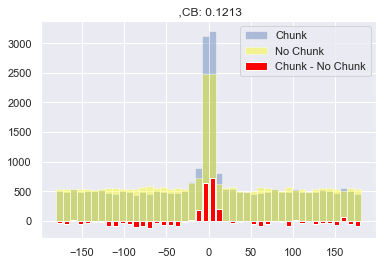

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


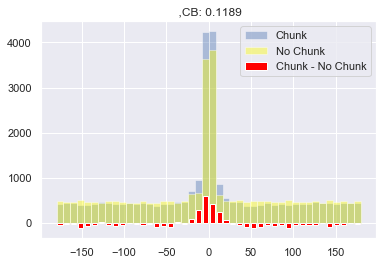

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/VarNonFixed/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


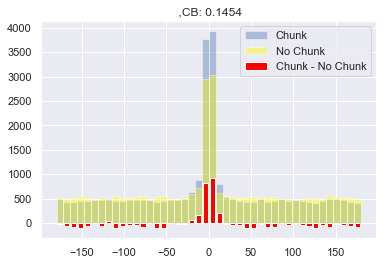

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


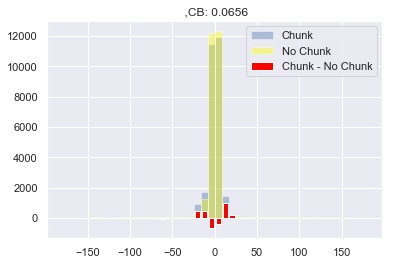

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


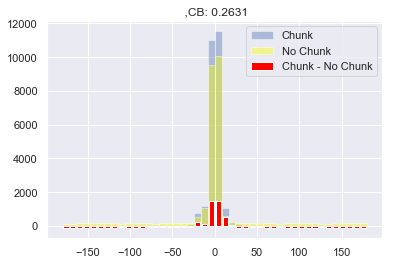

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "2"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


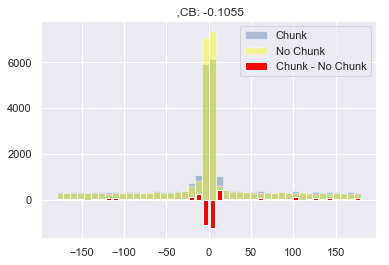

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip08/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


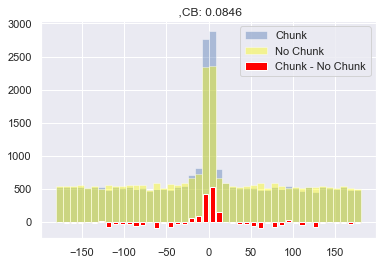

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Testfillstim/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


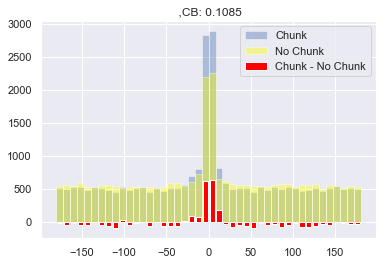

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstim/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


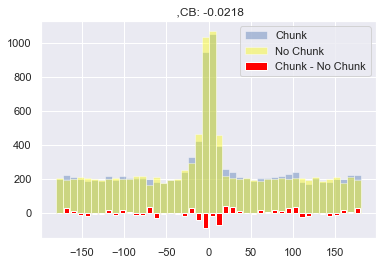

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/fillstimresetstim/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


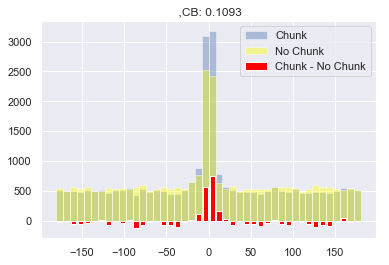

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


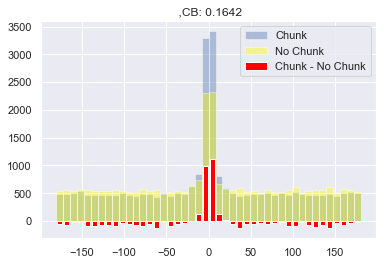

In [15]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/LR03/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


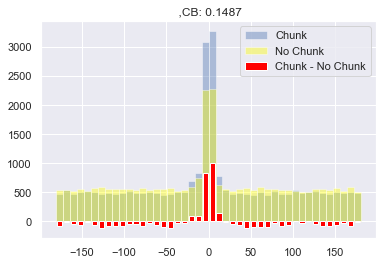

In [16]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/LR02/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


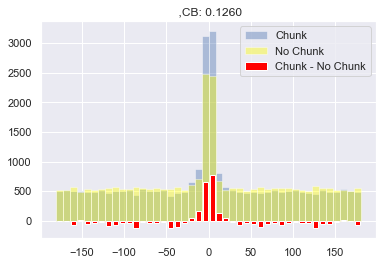

In [17]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80


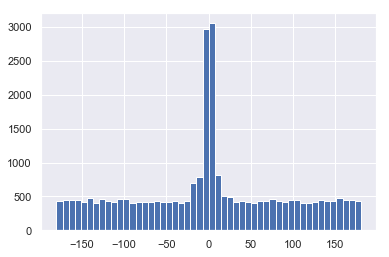

In [7]:
base_chunk = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/traintrials/"
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 50)
plt.show()

80


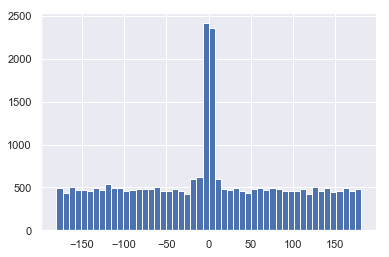

In [8]:
base_chunk = "Y:/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/traintrials/"
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
full_files = [f for f in full_files if 'TrialLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 50)
plt.show()

80


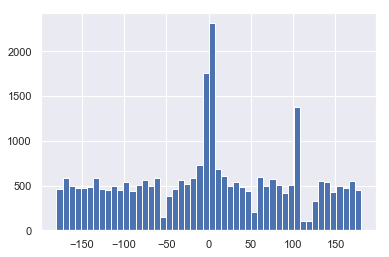

In [8]:

base_chunk = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrobjrecsched/"
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 50)
plt.show()

80


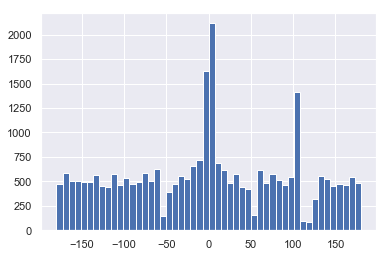

In [6]:

base_chunk = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lrinitmatrix/"
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 50)
plt.show()

80


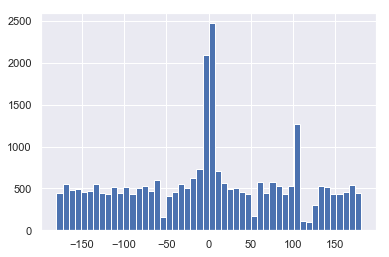

In [7]:

base_chunk = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lr1/"
files = os.listdir(base_chunk)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 50)
plt.show()

80


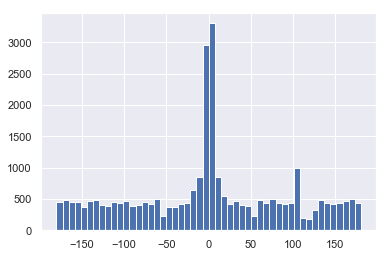

In [22]:

base_chunk = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
files = os.listdir(file)
files = [f for f in files if '.csv' in f]
full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
print(len(full_files))
p = Precision()
errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 50)
plt.show()

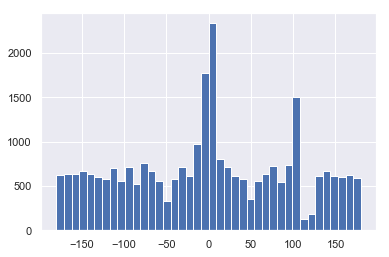

In [13]:

# base_chunk = "Y:/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/lr/"
# files = os.listdir(file)
# files = [f for f in files if '.csv' in f]
# full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
# print(len(full_files))
# p = Precision()
# errchunk = p.mult_models(full_files)
plt.hist(errchunk, bins = 40)
plt.show()

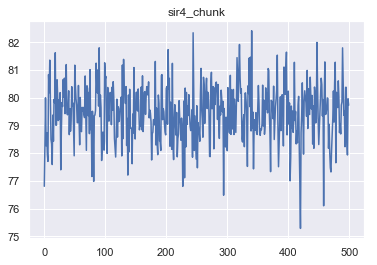

In [17]:
SSE, Epoch = training_curve_average(base_chunk)

80
80


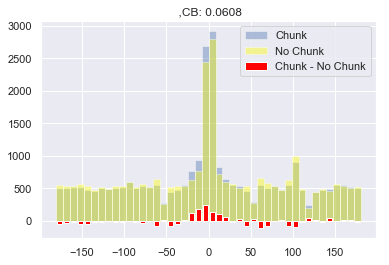

In [15]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst4/Dip16/TestNoGo125/"
task = "4"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


20


IndexError: list index out of range

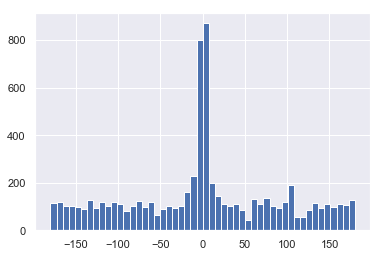

In [14]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/trial2/"
modelerr(base+'sir4_chunk/'+base2+'hybrid/'+experiment)
# p = Precision()

# err = p.mult_models([base+'sir4_chunk/'+base2+'hybrid/'+experiment])
# plt.hist(err)

80
80


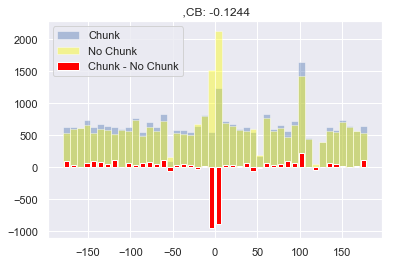

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip6/TestNoGo125/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


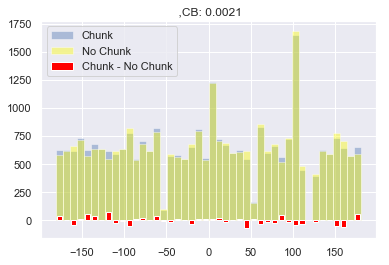

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/Burst12/Dip8/TestNoGo125/"
task = "3"
errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


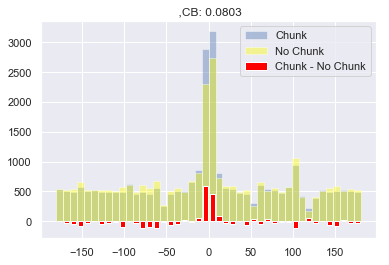

80
80


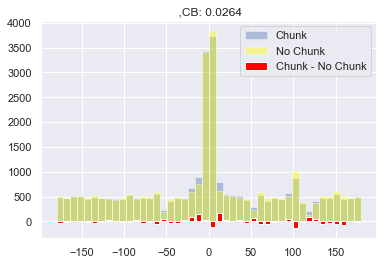

80
80


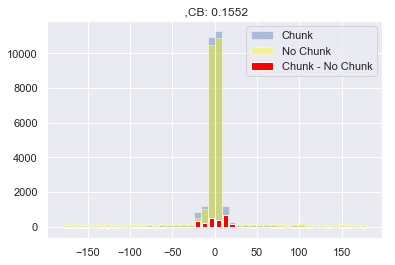

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG015/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


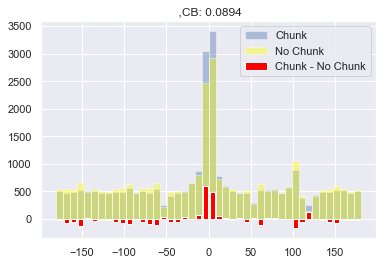

80
80


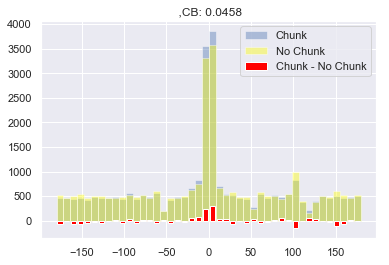

80
80


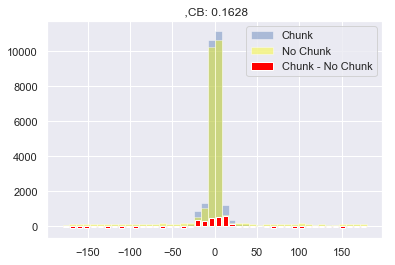

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG012/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


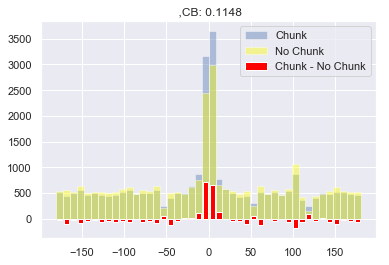

80
80


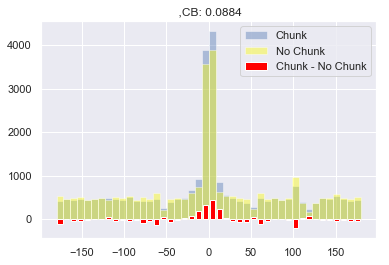

80
80


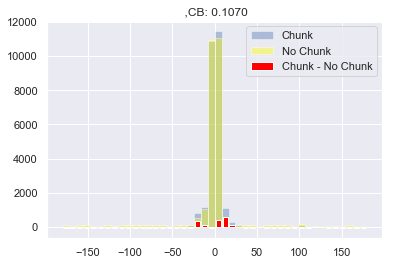

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG02/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


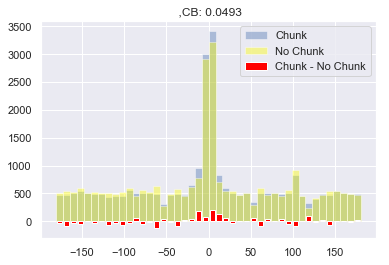

80
80


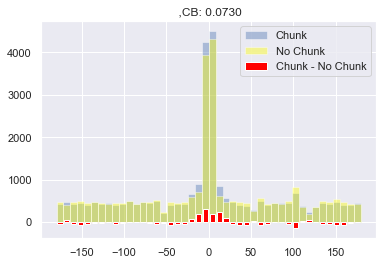

80
80


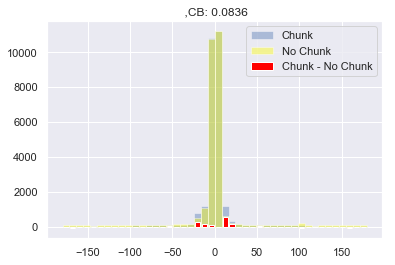

In [14]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG03/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


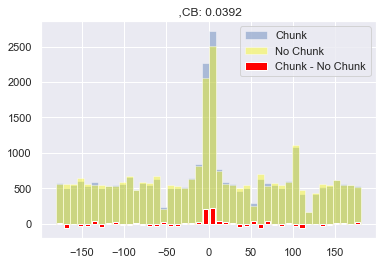

80
80


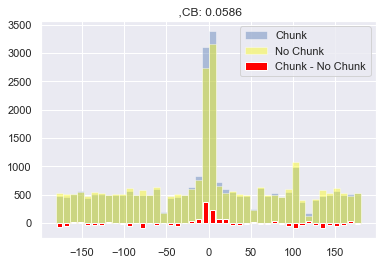

80
80


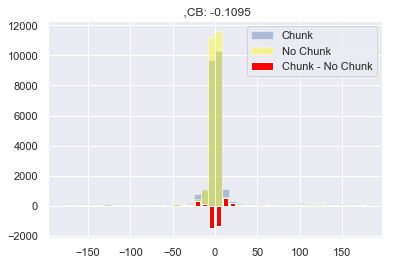

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG005/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


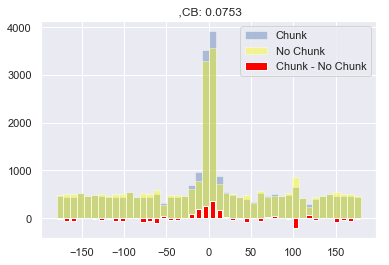

80
80


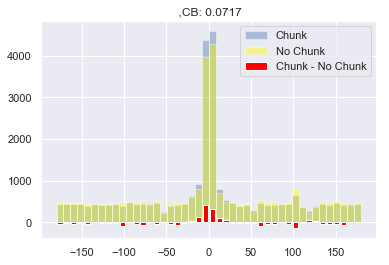

80
80


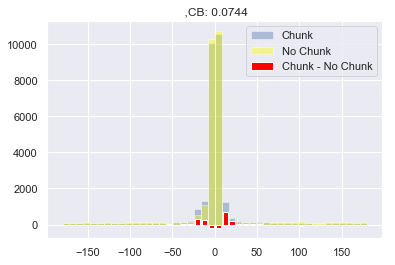

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG05/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


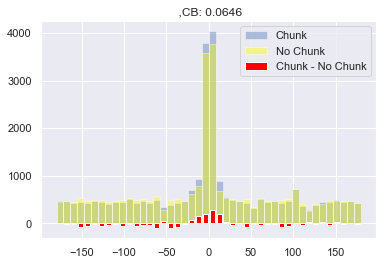

80
80


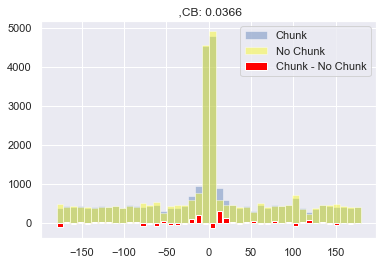

80
80


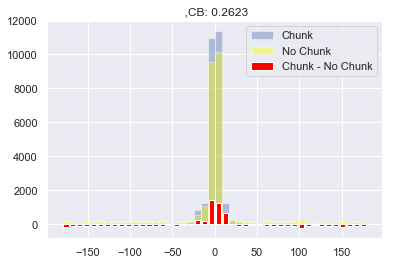

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG07/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


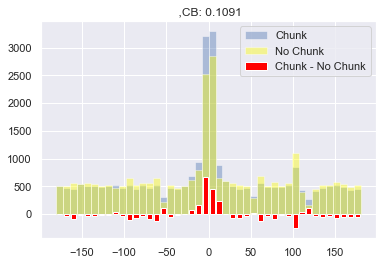

80
80


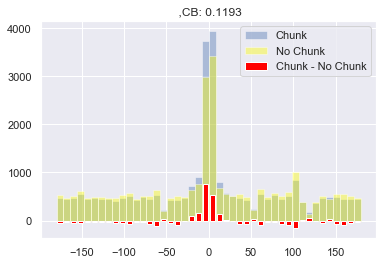

80
80


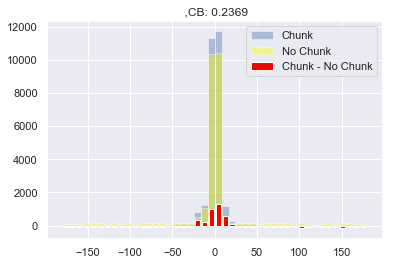

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarFixed/"
run_all(base,base2,experiment)

80
80


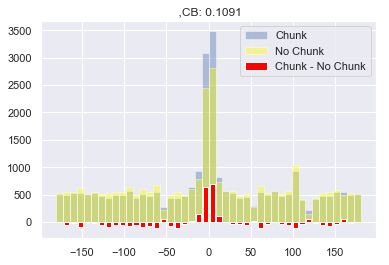

80
80


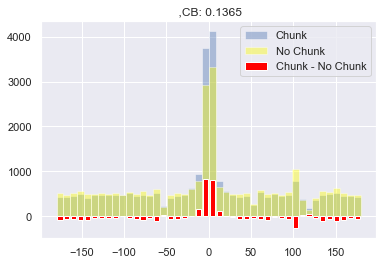

80
80


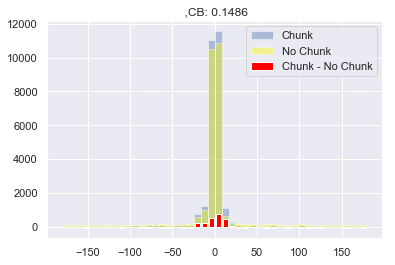

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/VarNonFixed/"
run_all(base,base2,experiment)

80
80


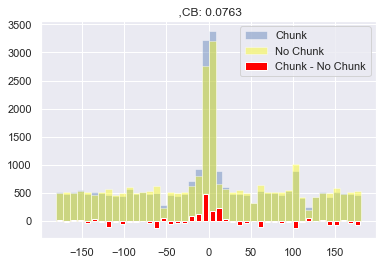

80
80


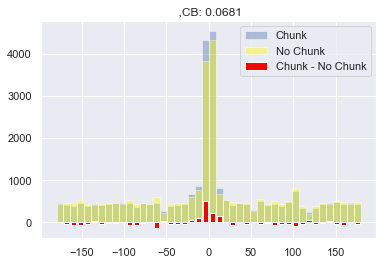

80
80


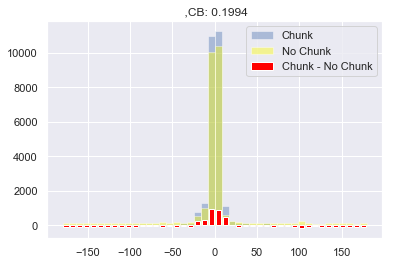

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG03/VmNoise/"
run_all(base,base2,experiment)

80
80


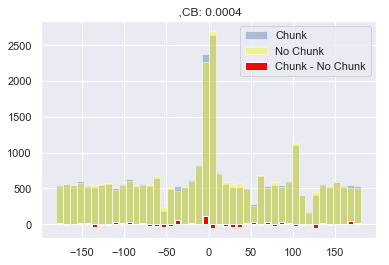

80
80


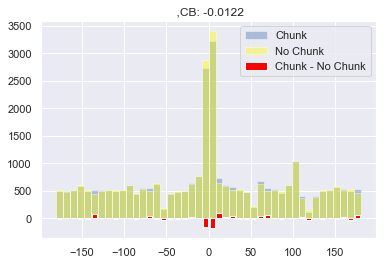

80
80


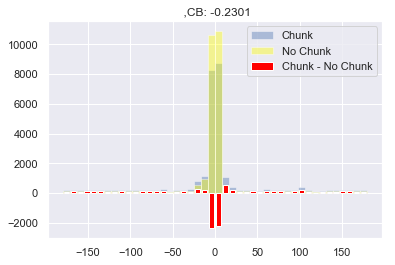

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG005/VmNoise/"
run_all(base,base2,experiment)

80
80


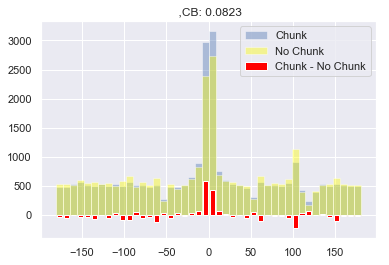

80
80


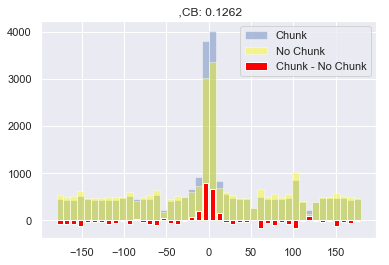

80
80


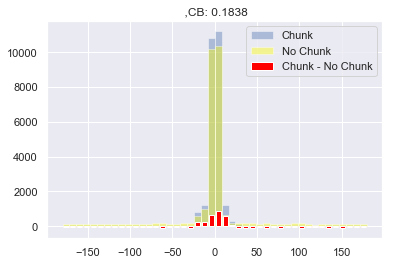

In [20]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise02/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise02/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise02/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)



79
80


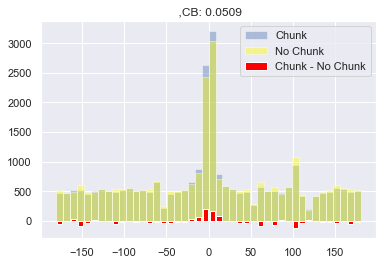

80
80


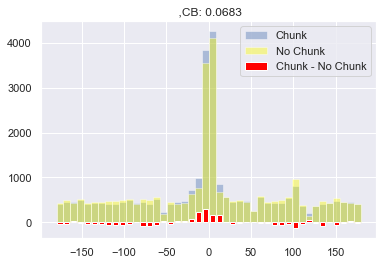

80
80


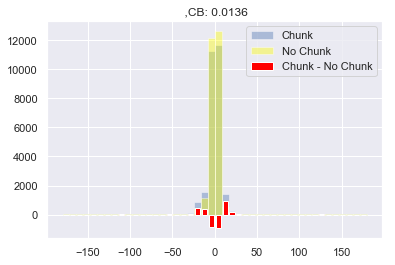

In [21]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)



80
80


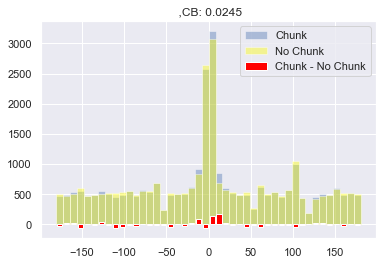

80
80


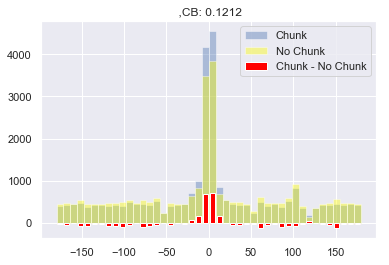

80
80


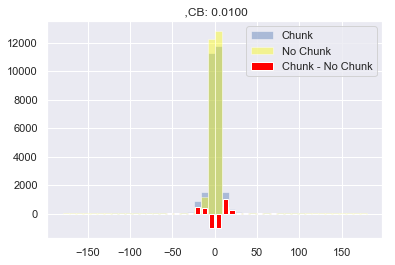

In [22]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise02/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)

base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise02/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/defaults/VmNoise02/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)



80
80


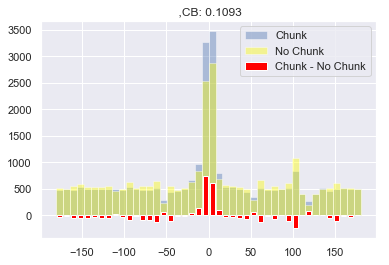

In [17]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


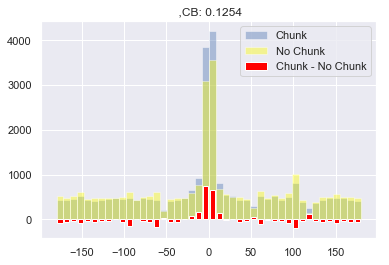

In [18]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


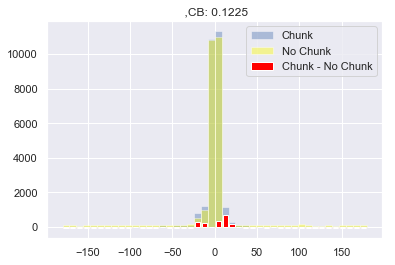

In [19]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/VmNoise/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


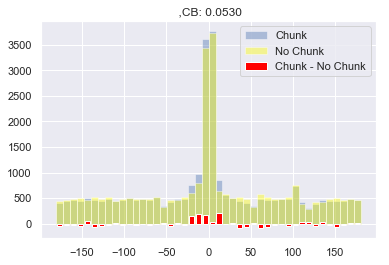

In [14]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/VmNoise/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


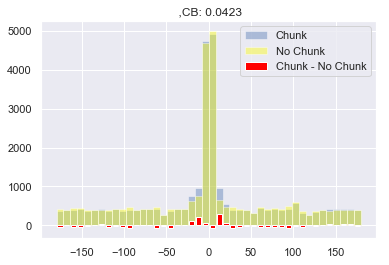

In [15]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/VmNoise/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


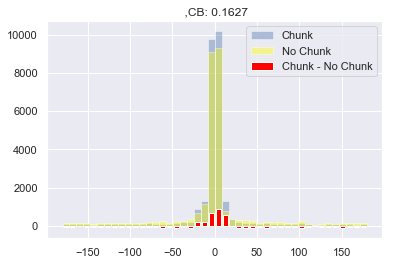

In [16]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/VmNoise/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


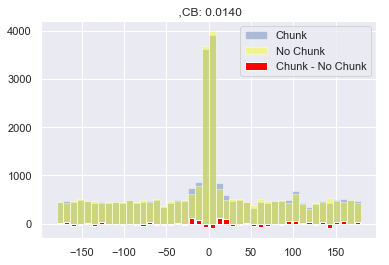

In [11]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


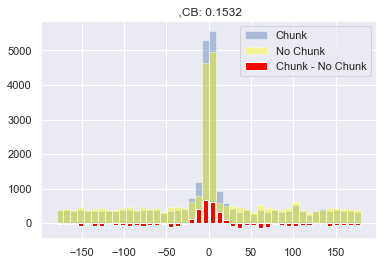

In [12]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


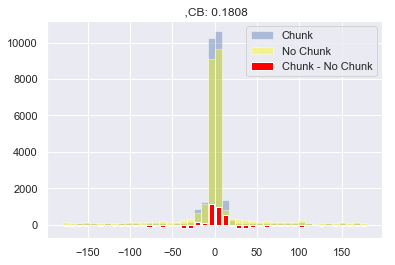

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaultsG1/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


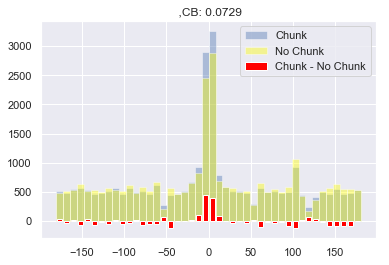

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


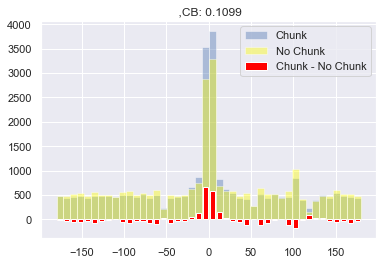

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


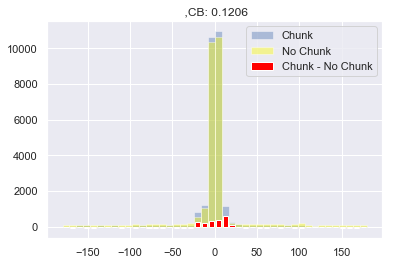

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/defaults/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


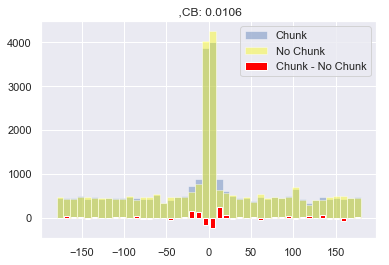

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


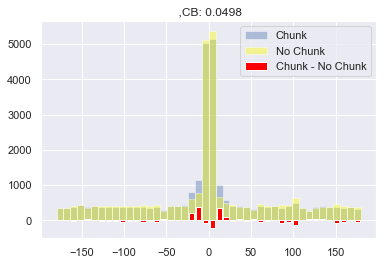

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


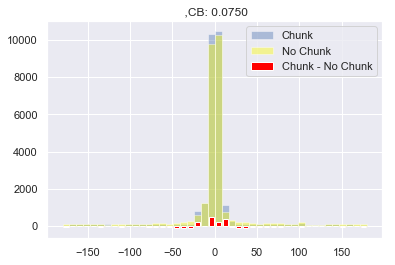

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/OneR/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


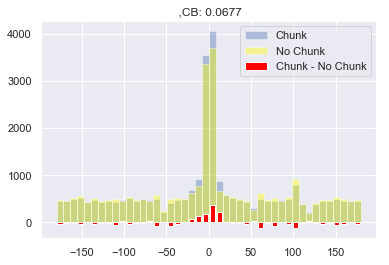

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/keepmod/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


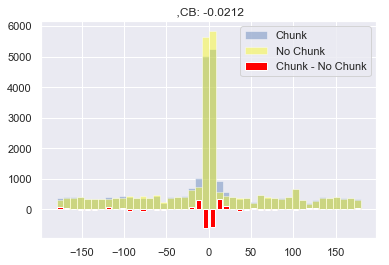

In [5]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/keepmod/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


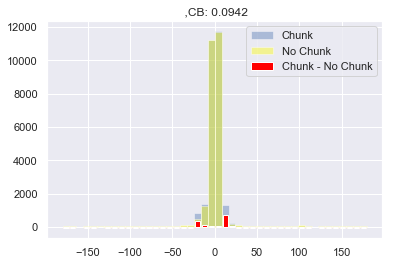

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/keepmod/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


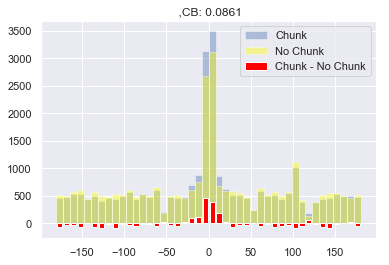

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contexpNoStimLoc/NoIgnore/nonresponse/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


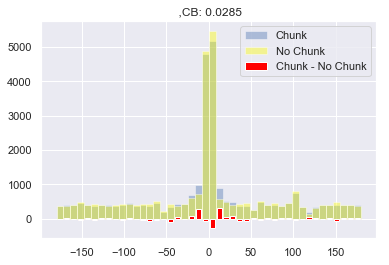

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contexpNoStimLoc/NoIgnore/nonresponse/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


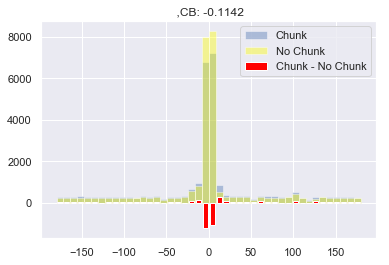

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contexpNoStimLoc/NoIgnore/nonresponse/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


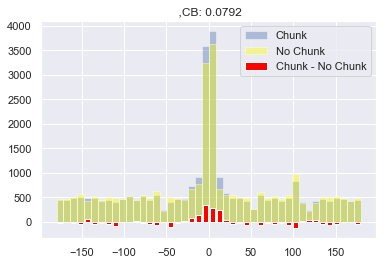

In [4]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


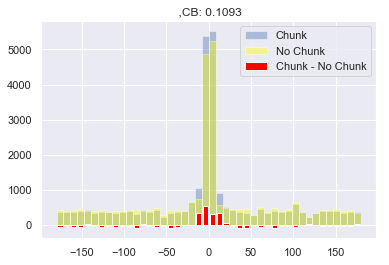

In [15]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "decodedrew/contNoStimLoc/NoIgnore/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


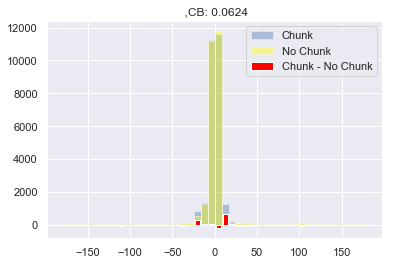

In [6]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


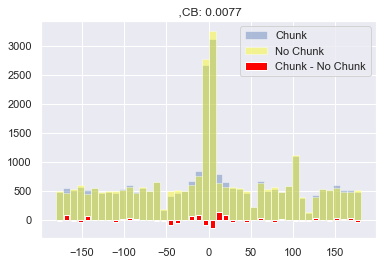

In [7]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Abs/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


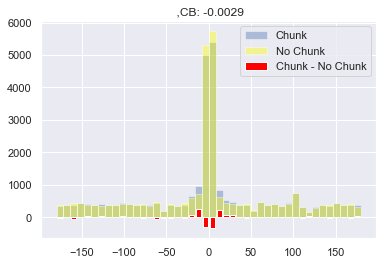

In [8]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Abs/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


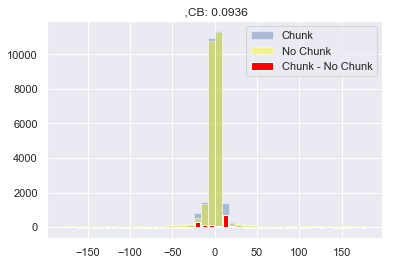

In [9]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Abs/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


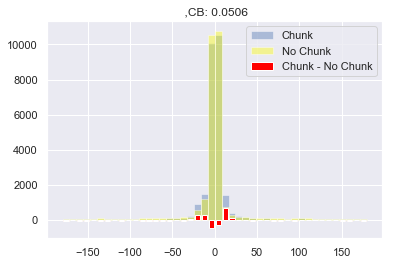

In [10]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
task = "2"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


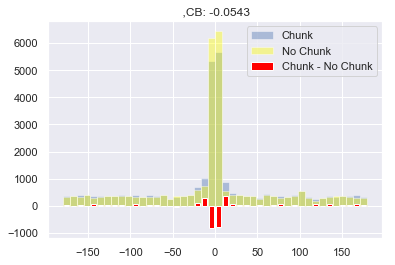

In [14]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
task = "3"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


80
80


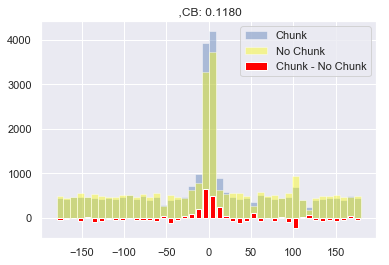

In [13]:
base = "Y:/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
task = "4"

errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment)


In [38]:
burstdip.index('Burst07Dip06')

23

In [226]:
len(nochunk_ABE_90_2)


11

In [17]:
list(sir2_chunking_benefit)

[0.0751734496817109,
 0.03647807739074458,
 0.013804448894928833,
 -0.058436449467133965,
 -0.19633788713253703,
 -0.13890279665259997,
 -0.3902439024390244,
 -0.3834489664544739,
 -0.5645518918532294,
 -0.6644016880051499,
 -0.7431514197839926,
 -0.019240397682569202,
 0.07216937272012017,
 0.03948215435233531]

In [5]:
sir2_chunking_benefit = list(np.load('sir2_chunking_benefit.npy'))
sir2_chunk_ABE = list(np.load('sir2_chunk_ABE.npy'))
sir2_nochunk_ABE = list(np.load('sir2_nochunk_ABE.npy'))
sir2_chunking_benefit_45 = list(np.load('sir2_chunking_benefit_45.npy'))
sir2_chunk_ABE_45 = list(np.load('sir2_chunk_ABE_45.npy'))
sir2_nochunk_ABE_45 = list(np.load('sir2_nochunk_ABE_45.npy'))
sir2_chunking_benefit_90 = list(np.load('sir2_chunking_benefit_90.npy'))
sir2_chunk_ABE_90 = list(np.load('sir2_chunk_ABE_90.npy'))
sir2_nochunk_ABE_90 = list(np.load('sir2_nochunk_ABE_90.npy'))
sir2_burstdip = list(np.load('sir2_burstdip.npy'))

In [12]:
sir3_2_chunking_benefit_45 = sir3_2_chunking_benefit_45[:-1]
sir3_2_chunk_ABE_45  = sir3_2_chunk_ABE_45[:-1]
sir3_2_nochunk_ABE_45 = sir3_2_nochunk_ABE_45[:-1]

In [23]:
len(sir3_chunking_benefit_NR)

49

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip16/
80
80


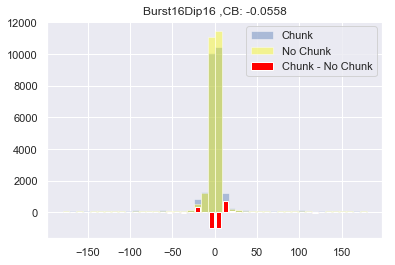

In [31]:
#started 11:20
# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


# Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
# BurstName =["04", "06", "08", "1", "12", "14", "16"]
# DipName = ["04", "06", "08", "1", "12", "14", "16"]


Burst = [1.6]
Dip = [1.6]
BurstName =["16"]
DipName = ["16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "2"


# sir2_chunking_benefit_NR= []
# sir2_chunk_ABE_NR = []
# sir2_nochunk_ABE_NR = []
# sir2_burstdip_NR = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        sir2_chunking_benefit_NR.append(CB)
        sir2_chunk_ABE_NR.append(total_mean_chunk)
        sir2_nochunk_ABE_NR.append(total_mean_nochunk)
        
        np.save('sir2_chunking_benefit_NR.npy',np.array(sir2_chunking_benefit_NR))
        np.save('sir2_chunk_ABE_NR.npy',np.array(sir2_chunk_ABE_NR))
        np.save('sir2_nochunk_ABE_NR.npy',np.array(sir2_nochunk_ABE_NR))
        sir2_burstdip_NR.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        np.save('sir2_burstdip_NR.npy', np.array(sir2_burstdip_NR))
        #import pdb; pdb.set_trace()
        

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip04/
80
80


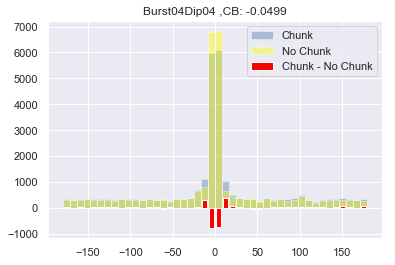

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip06/
80
80


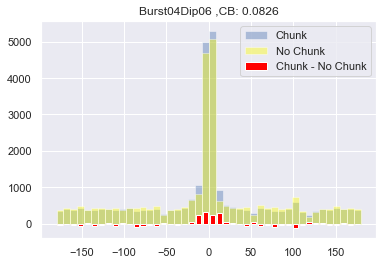

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip08/
80
80


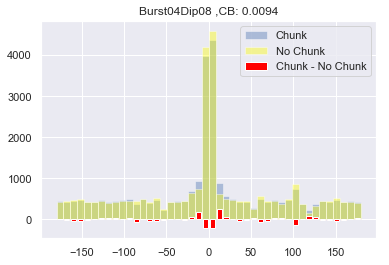

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip1/
80
80


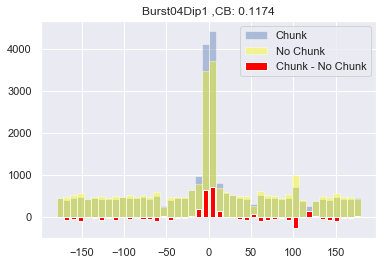

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip12/
80
80


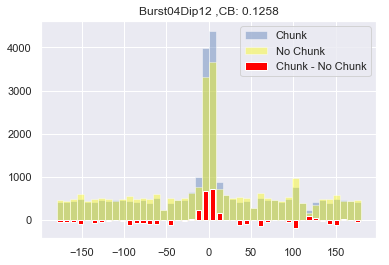

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip14/
80
80


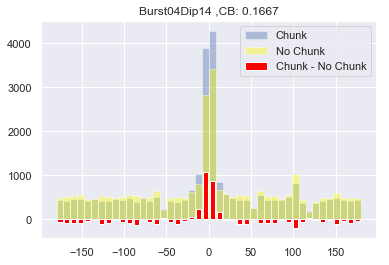

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst04/Dip16/
80
80


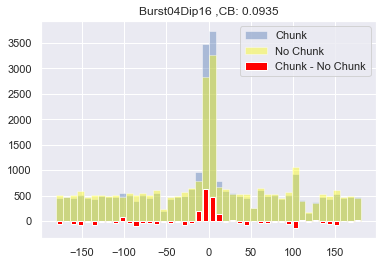

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip04/
80
80


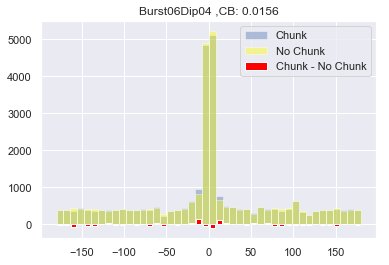

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip06/
80
80


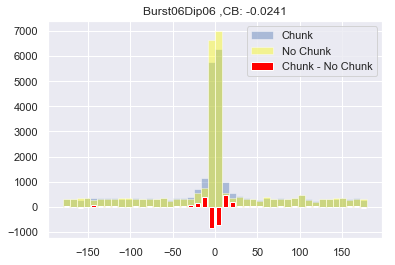

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip08/
80
80


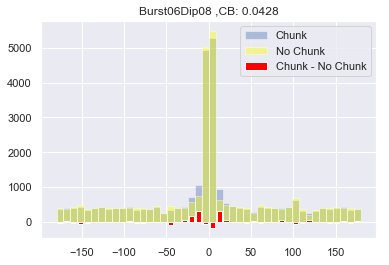

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip1/
80
80


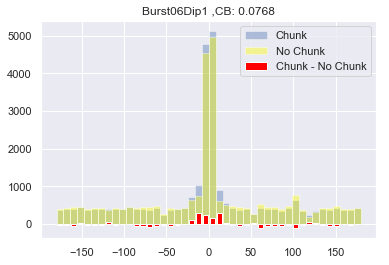

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip12/
80
80


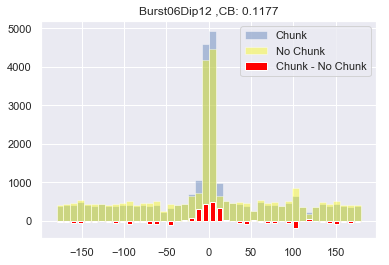

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip14/
80
80


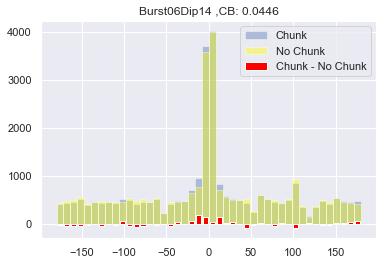

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst06/Dip16/
80
80


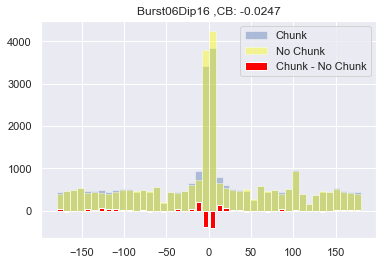

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip04/
80
80


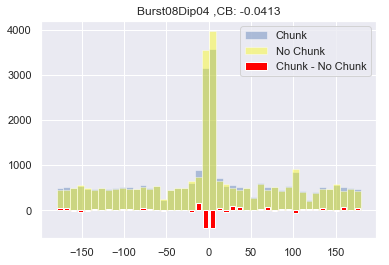

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip06/
80
80


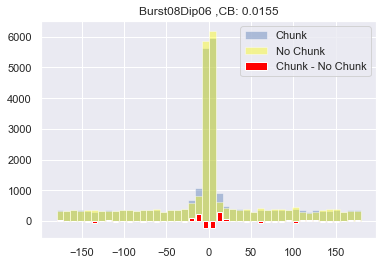

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip08/
80
80


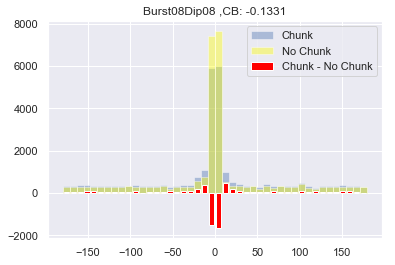

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip1/
80
80


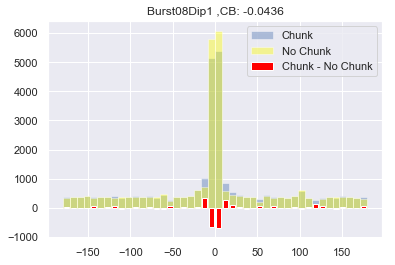

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip12/
80
80


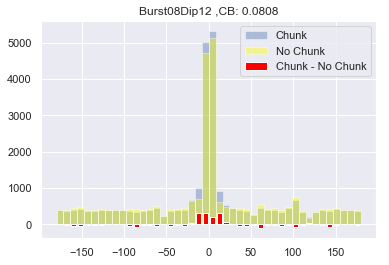

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip14/
80
80


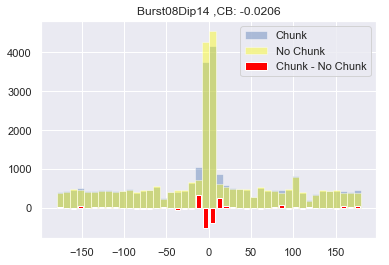

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst08/Dip16/
80
80


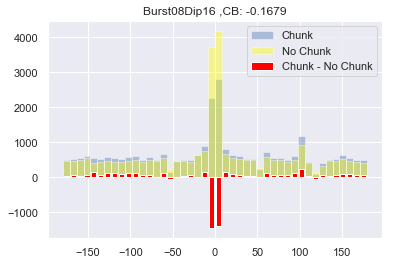

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip04/
80
80


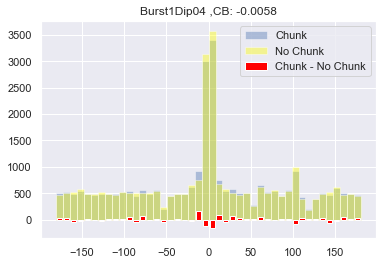

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip06/
80
80


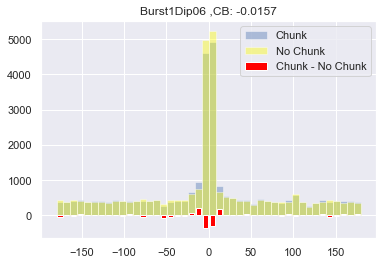

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip08/
80
80


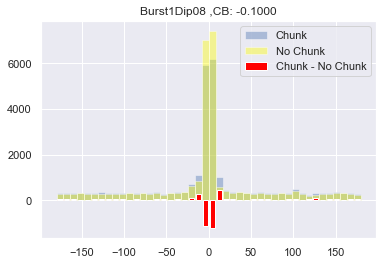

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip1/
80
80


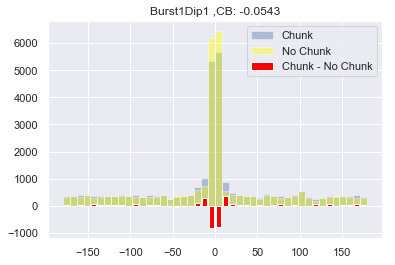

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip12/
80
80


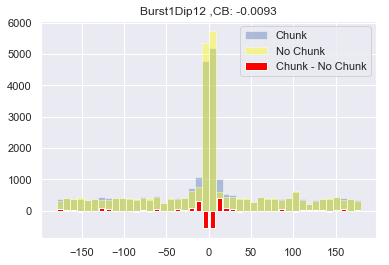

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip14/
80
80


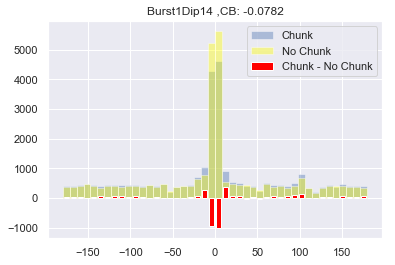

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst1/Dip16/
80
80


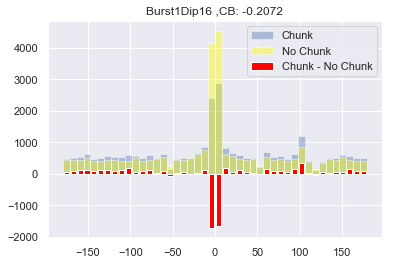

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip04/
80
80


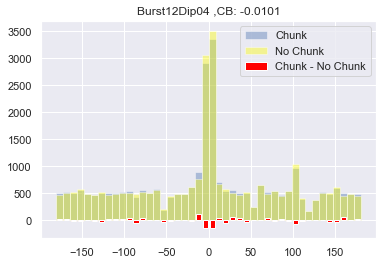

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip06/
80
80


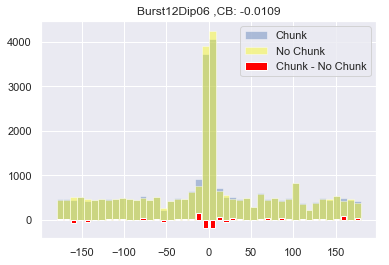

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip08/
80
80


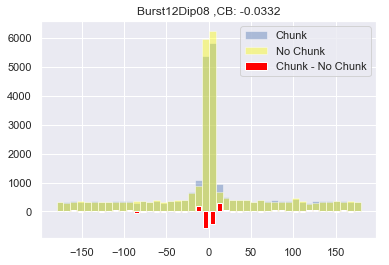

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip1/
80
80


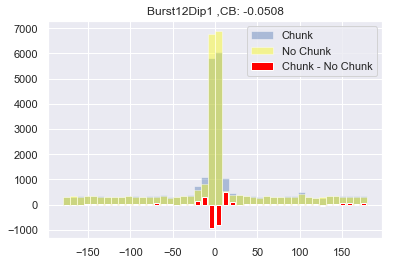

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip12/
80
80


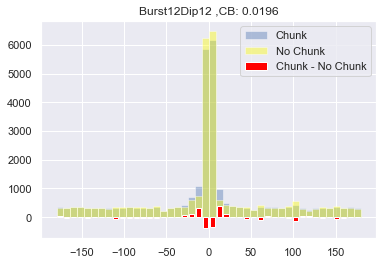

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip14/
80
80


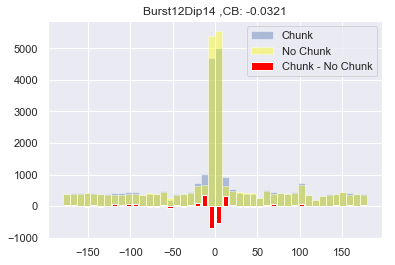

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip16/
80
80


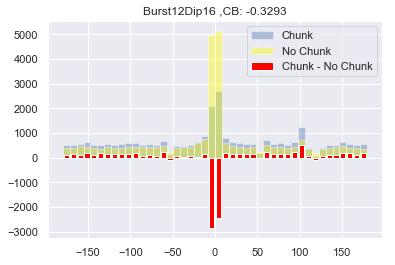

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip04/
80
80


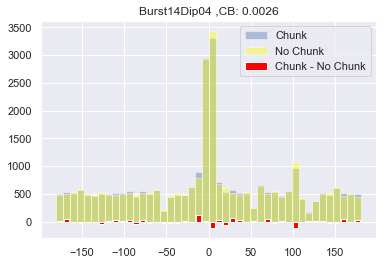

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip06/
80
80


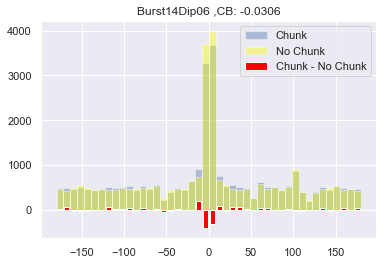

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip08/
80
80


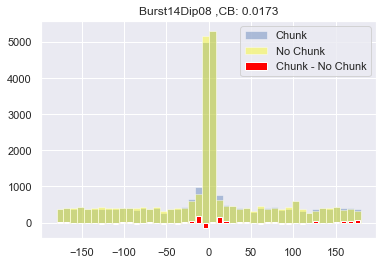

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip1/
80
80


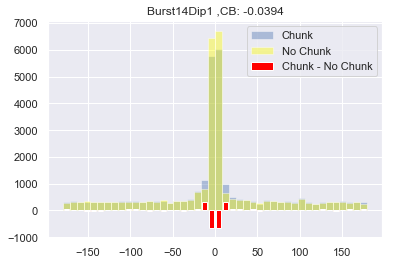

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip12/
80
80


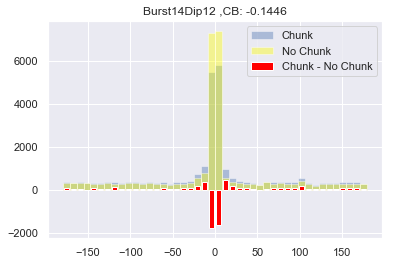

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip14/
80
80


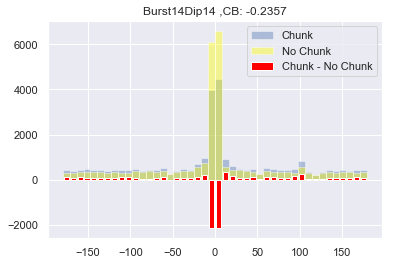

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip16/
80
80


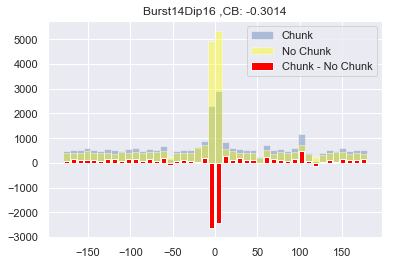

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip04/
80
80


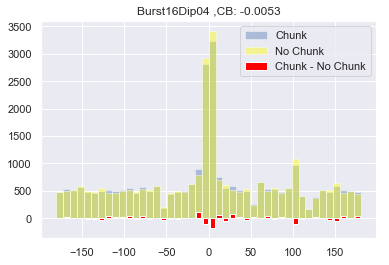

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip06/
80
80


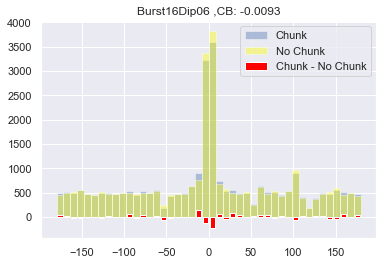

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip08/
80
80


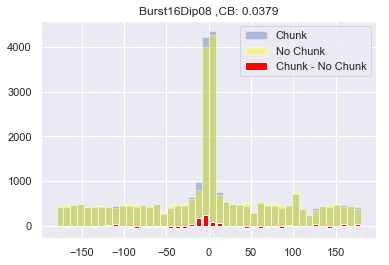

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip1/
80
80


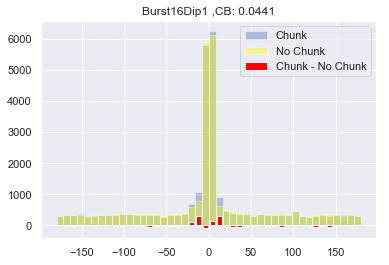

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip12/
80
80


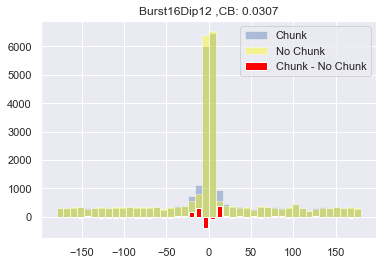

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip14/
80
80


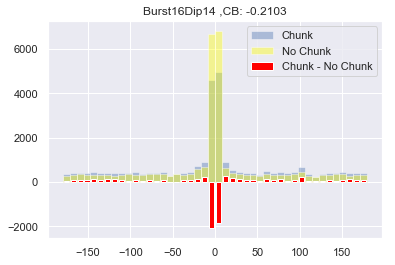

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip16/
80
80


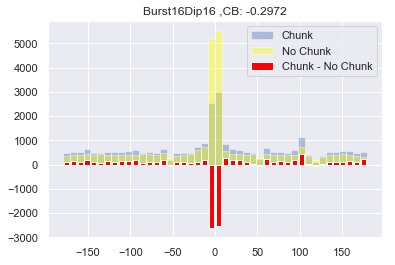

In [21]:
# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["04", "06", "08", "1", "12", "14", "16"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "3"



sir3_chunking_benefit_NR= []
sir3_chunk_ABE_NR = []
sir3_nochunk_ABE_NR = []
sir3_burstdip_NR = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        sir3_chunking_benefit_NR.append(CB)
        sir3_chunk_ABE_NR.append(total_mean_chunk)
        sir3_nochunk_ABE_NR.append(total_mean_nochunk)
        
        np.save('sir3_chunking_benefit_NR.npy',np.array(sir3_chunking_benefit_NR))
        np.save('sir3_chunk_ABE_NR.npy',np.array(sir3_chunk_ABE_NR))
        np.save('sir3_nochunk_ABE_NR.npy',np.array(sir3_nochunk_ABE_NR))
        sir3_burstdip_NR.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        np.save('sir3_burstdip_NR.npy', np.array(sir3_burstdip_NR))
        #import pdb; pdb.set_trace()
        

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip04/
80
80


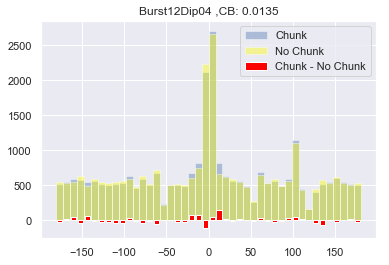

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip06/
80
80


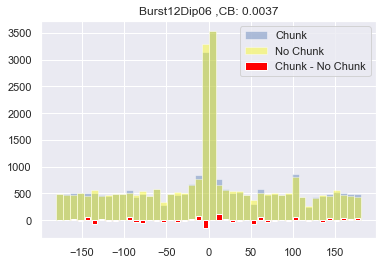

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip08/
80
80


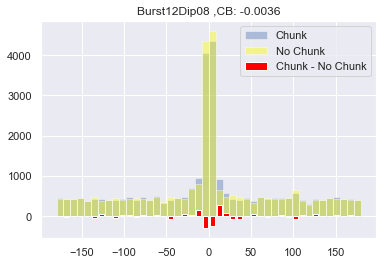

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip1/
80
80


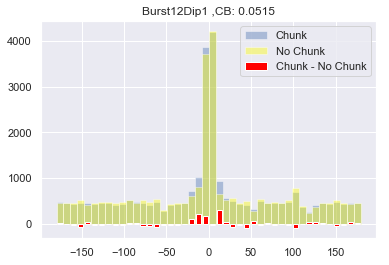

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip12/
80
80


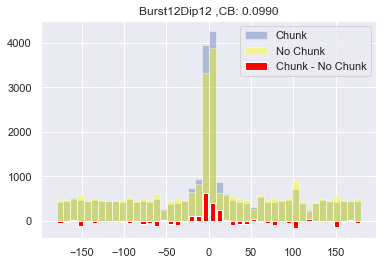

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip14/
80
80


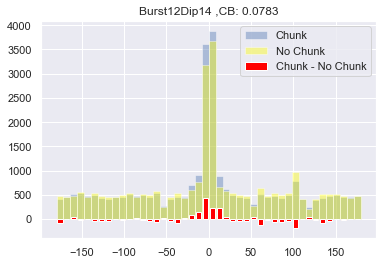

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst12/Dip16/
80
80


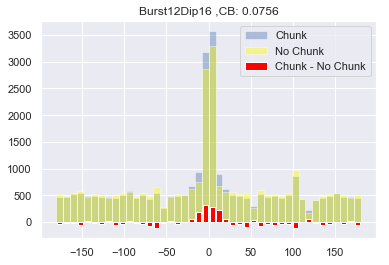

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip04/
80
80


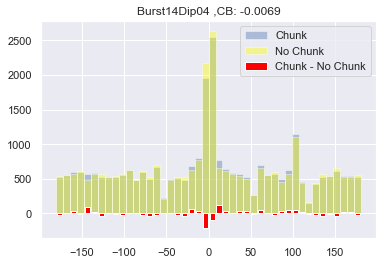

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip06/
80
80


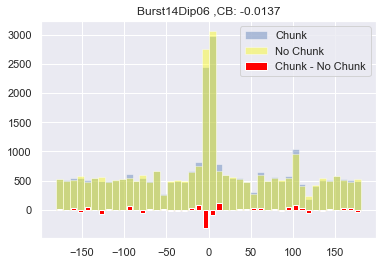

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip08/
80
80


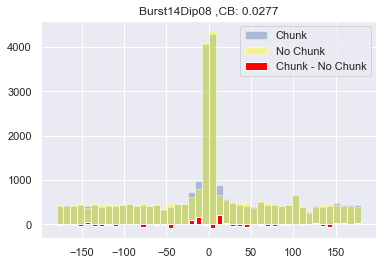

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip1/
80
80


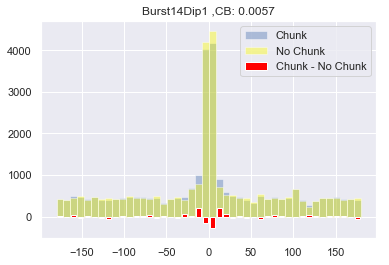

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip12/
80
80


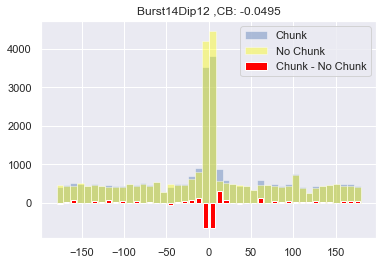

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip14/
80
80


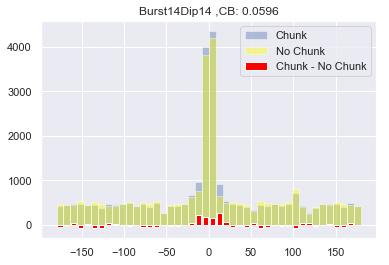

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst14/Dip16/
80
80


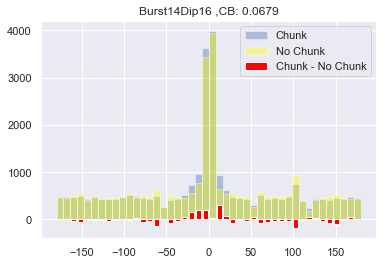

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip04/
80
80


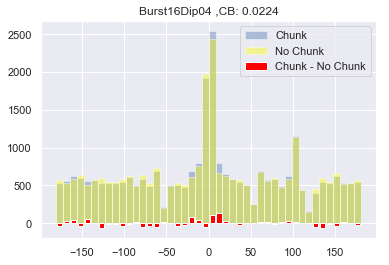

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip06/
80
80


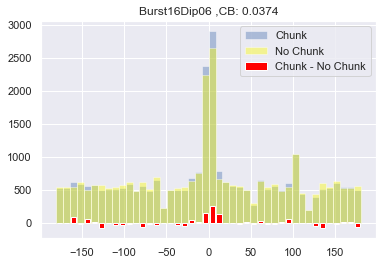

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip08/
80
80


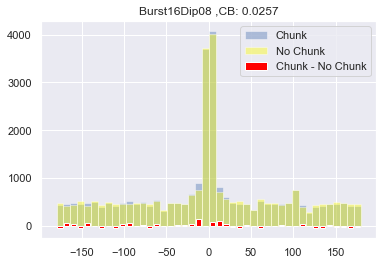

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip1/
80
80


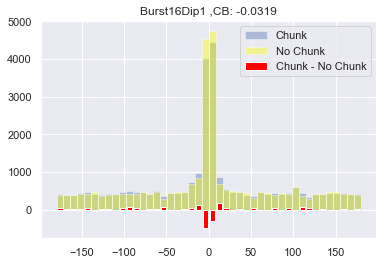

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip12/
80
80


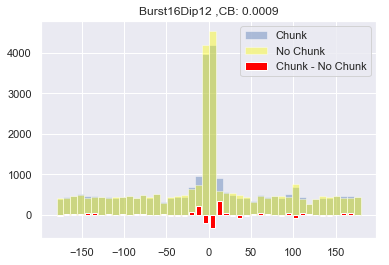

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip14/
80
80


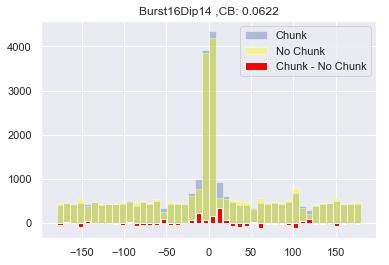

decodedrew/contNoStimLoc/NoIgnore/nonresponse/Burst16/Dip16/
80
80


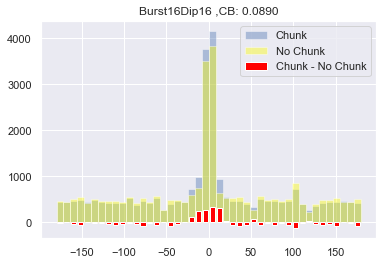

In [32]:
# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


Burst = [1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["12", "14", "16"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]

#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "4"



# sir4_chunking_benefit_NR= []
# sir4_chunk_ABE_NR = []
# sir4_nochunk_ABE_NR = []
# sir4_burstdip_NR = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        experiment = expbase+gain
        print(experiment)
        name = "Burst"+BurstName[burst]+"Dip"+DipName[dip].replace('/','')
        errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
        #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        sir4_chunking_benefit_NR.append(CB)
        sir4_chunk_ABE_NR.append(total_mean_chunk)
        sir4_nochunk_ABE_NR.append(total_mean_nochunk)
        
        np.save('sir4_chunking_benefit_NR.npy',np.array(sir4_chunking_benefit_NR))
        np.save('sir4_chunk_ABE_NR.npy',np.array(sir4_chunk_ABE_NR))
        np.save('sir4_nochunk_ABE_NR.npy',np.array(sir4_nochunk_ABE_NR))
        sir4_burstdip_NR.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        np.save('sir4_burstdip_NR.npy', np.array(sir4_burstdip_NR))
        #import pdb; pdb.set_trace()
        

In [33]:
len(sir2_chunking_benefit_NR)

49

In [ ]:
# Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
# Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
# BurstName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
# DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]


Burst = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
Dip = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
BurstName =["04", "06", "08", "1", "12", "14", "16"]
DipName = ["04", "06", "08", "1", "12", "14", "16"]

tests = ['Test45/','Test90/','']
#base = "Z:/leabra/examples/workingmemory/"
base = "Y:/"
base2 = "results/Ring/2Stripe/"
task = "4"



sir4_chunking_benefit_NR= []
sir4_chunk_ABE_NR = []
sir4_nochunk_ABE_NR = []
sir4_chunking_benefit_45_NR = []
sir4_chunk_ABE_45_NR = []
sir4_nochunk_ABE_45_NR = []
sir4_chunking_benefit_90_NR = []
sir4_chunk_ABE_90_NR = []
sir4_nochunk_ABE_90_NR = []
sir4_burstdip_NR = []

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/nonresponse/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        for i in tests:
            test = i 
            experiment = expbase+gain + test
            print(experiment)
            name = "Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')
            errchunk, err, ax, diff, CB, total_mean_chunk, total_mean_nochunk,std_chunk, std_nochunk = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png", ABE = True)
            #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
            if i == 'Test45/':
                sir4_chunking_benefit_45_NR.append(CB)
                sir4_chunk_ABE_45_NR.append(total_mean_chunk)
                sir4_nochunk_ABE_45_NR.append(total_mean_nochunk)        
        
            if i == 'Test90/':
                sir4_chunking_benefit_90_NR.append(CB)
                sir4_chunk_ABE_90_NR.append(total_mean_chunk)
                sir4_nochunk_ABE_90_NR.append(total_mean_nochunk)
                
            if i == '':
                sir4_chunking_benefit_NR.append(CB)
                sir4_chunk_ABE_NR.append(total_mean_chunk)
                sir4_nochunk_ABE_NR.append(total_mean_nochunk)
        
        np.save('sir4_chunking_benefit_NR.npy',np.array(sir4_chunking_benefit_NR))
        np.save('sir4_chunk_ABE_NR.npy',np.array(sir4_chunk_ABE_NR))
        np.save('sir4_nochunk_ABE_NR.npy',np.array(sir4_nochunk_ABE_NR))
        np.save('sir4_chunking_benefit_45_NR.npy',np.array(sir4_chunking_benefit_45_NR))
        np.save('sir4_chunk_ABE_45_NR.npy',np.array(sir4_chunk_ABE_45_NR))
        np.save('sir4_nochunk_ABE_45_NR.npy',np.array(sir4_nochunk_ABE_45_NR)) 
        np.save('sir4_chunking_benefit_90_NR.npy',np.array(sir4_chunking_benefit_90_NR))
        np.save('sir4_chunk_ABE_90_NR.npy',np.array(sir4_chunk_ABE_90_NR))
        np.save('sir4_nochunk_ABE_90_NR.npy',np.array(sir4_nochunk_ABE_90_NR))
        sir4_burstdip_NR.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
        np.save('sir4_burstdip_NR.npy', np.array(sir4_burstdip_NR))
        #import pdb; pdb.set_trace()
        

In [17]:
ex = np.load('sir2_chunking_benefit.npy')

In [18]:
len(ex)

121

In [38]:
sir2_chunking_benefit_45 = sir2_chunking_benefit_45[:-1]
sir2_chunk_ABE_45  = sir2_chunk_ABE_45[:-1]
sir2_nochunk_ABE_45 = sir2_nochunk_ABE_45[:-1]

In [228]:
np.save('chunking_benefit_2.npy',np.array(chunking_benefit_2))
np.save('chunk_ABE_2.npy',np.array(chunk_ABE_2))
np.save('nochunk_ABE_2.npy',np.array(nochunk_ABE_2))
np.save('chunking_benefit_45_2.npy',np.array(chunking_benefit_45_2))
np.save('chunk_ABE_45_2.npy',np.array(chunk_ABE_45_2))
np.save('nochunk_ABE_45_2.npy',np.array(nochunk_ABE_45_2)) 
np.save('chunking_benefit_90_2.npy',np.array(chunking_benefit_90_2))
np.save('chunk_ABE_90_2.npy',np.array(chunk_ABE_90_2))
np.save('nochunk_ABE_90_2.npy',np.array(nochunk_ABE_90_2))

Burst = [0.8,0.9,1.0,1.1,1.2]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
BurstName = ["08", "09", "1", "11","12"]
DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]

burstdip2 = []
for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        burstdip2.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
np.save('burstdip2.npy', np.array(burstdip2))

In [256]:
Burst = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
BurstName = ["0.5", "0.6", "0.7", "0.8", "0.9", "1.0", "1.1", "1.2", "1.3","1.4", "1.5"]
DipName = ["0.5", "0.6", "0.7", "0.8", "0.9", "1.0", "1.1", "1.2", "1.3","1.4", "1.5"]
burstdipall = []
for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        burstdipall.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
np.save('burstdipall.npy', np.array(burstdipall))


In [275]:
chunk_ABE_all_45[113]

28.22497880262826

In [276]:
burstdipall[113]

'Burst1.5Dip0.8'

In [208]:
np.save('chunking_benefit.npy',np.array(chunking_benefit))
np.save('chunk_ABE.npy',np.array(chunk_ABE))
np.save('nochunk_ABE.npy',np.array(nochunk_ABE))
np.save('chunking_benefit_45.npy',np.array(chunking_benefit_45))
np.save('chunk_ABE_45.npy',np.array(chunk_ABE_45))
np.save('nochunk_ABE_45.npy',np.array(nochunk_ABE_45)) 
np.save('chunking_benefit_90.npy',np.array(chunking_benefit_90))
np.save('chunk_ABE_90.npy',np.array(chunk_ABE_90))
np.save('nochunk_ABE_90.npy',np.array(nochunk_ABE_90))

Burst = [0.5,0.6,0.7,1.3,1.4,1.5]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
BurstName = ["05", "06", "07", "13","14", "15"]
DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]

burstdip = []
for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        burstdip.append("Burst"+str(BurstName[burst])+"Dip"+str(DipName[dip]))
np.save('burstdip.npy', np.array(burstdip))

In [ ]:
Burst = [0.5,0.6,0.7,1.3,1.4,1.5]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]

In [25]:
sir3_chunking_benefit_all = np.concatenate((np.load('sir3_chunking_benefit.npy'), np.load('sir306_chunking_benefit.npy'), 
                                           np.load('sir307_chunking_benefit.npy'),np.load('sir308_chunking_benefit.npy'),
                                          np.load('sir309_chunking_benefit.npy'),np.load('sir3_2_chunking_benefit.npy'),
                                          np.load('sir314_chunking_benefit.npy'),np.load('sir315_chunking_benefit.npy')))

In [26]:
len(sir3_chunking_benefit_all)

118

In [27]:
sir3_chunking_benefit_all = np.concatenate((np.load('sir3_chunking_benefit.npy'), np.load('sir306_chunking_benefit.npy'), 
                                           np.load('sir307_chunking_benefit.npy'),np.load('sir308_chunking_benefit.npy'),
                                          np.load('sir309_chunking_benefit.npy'),np.load('sir3_2_chunking_benefit.npy'),
                                          np.load('sir314_chunking_benefit.npy'),np.load('sir315_chunking_benefit.npy')))
sir3_chunking_benefit_all_45 = np.concatenate((np.load('sir3_chunking_benefit_45.npy'), np.load('sir306_chunking_benefit_45.npy'), 
                                           np.load('sir307_chunking_benefit_45.npy'),np.load('sir308_chunking_benefit_45.npy'),
                                          np.load('sir309_chunking_benefit_45.npy'),np.load('sir3_2_chunking_benefit_45.npy'),
                                          np.load('sir314_chunking_benefit_45.npy'),np.load('sir315_chunking_benefit_45.npy')))
sir3_chunking_benefit_all_90 = np.concatenate((np.load('sir3_chunking_benefit_90.npy'), np.load('sir306_chunking_benefit_90.npy'), 
                                           np.load('sir307_chunking_benefit_90.npy'),np.load('sir308_chunking_benefit_90.npy'),
                                          np.load('sir309_chunking_benefit_90.npy'),np.load('sir3_2_chunking_benefit_90.npy'),
                                          np.load('sir314_chunking_benefit_90.npy'),np.load('sir315_chunking_benefit_90.npy')))

sir3_chunk_ABE_all = np.concatenate((np.load('sir3_chunk_ABE.npy'), np.load('sir306_chunk_ABE.npy'), 
                                           np.load('sir307_chunk_ABE.npy'),np.load('sir308_chunk_ABE.npy'),
                                          np.load('sir309_chunk_ABE.npy'),np.load('sir3_2_chunk_ABE.npy'),
                                          np.load('sir314_chunk_ABE.npy'),np.load('sir315_chunk_ABE.npy')))
sir3_chunk_ABE_all_45 = np.concatenate((np.load('sir3_chunk_ABE_45.npy'), np.load('sir306_chunk_ABE_45.npy'), 
                                           np.load('sir307_chunk_ABE_45.npy'),np.load('sir308_chunk_ABE_45.npy'),
                                          np.load('sir309_chunk_ABE_45.npy'),np.load('sir3_2_chunk_ABE_45.npy'),
                                          np.load('sir314_chunk_ABE_45.npy'),np.load('sir315_chunk_ABE_45.npy')))
sir3_chunk_ABE_all_90 =np.concatenate((np.load('sir3_chunk_ABE_90.npy'), np.load('sir306_chunk_ABE_90.npy'), 
                                           np.load('sir307_chunk_ABE_90.npy'),np.load('sir308_chunk_ABE_90.npy'),
                                          np.load('sir309_chunk_ABE_90.npy'),np.load('sir3_2_chunk_ABE_90.npy'),
                                          np.load('sir314_chunk_ABE_90.npy'),np.load('sir315_chunk_ABE_90.npy')))

sir3_nochunk_ABE_all =np.concatenate((np.load('sir3_nochunk_ABE.npy'), np.load('sir306_nochunk_ABE.npy'), 
                                           np.load('sir307_nochunk_ABE.npy'),np.load('sir308_nochunk_ABE.npy'),
                                          np.load('sir309_nochunk_ABE.npy'),np.load('sir3_2_nochunk_ABE.npy'),
                                          np.load('sir314_nochunk_ABE.npy'),np.load('sir315_nochunk_ABE.npy')))
sir3_nochunk_ABE_all_45 = np.concatenate((np.load('sir3_nochunk_ABE_45.npy'), np.load('sir306_nochunk_ABE_45.npy'), 
                                           np.load('sir307_nochunk_ABE_45.npy'),np.load('sir308_nochunk_ABE_45.npy'),
                                          np.load('sir309_nochunk_ABE_45.npy'),np.load('sir3_2_nochunk_ABE_45.npy'),
                                          np.load('sir314_nochunk_ABE_45.npy'),np.load('sir315_nochunk_ABE_45.npy')))
sir3_nochunk_ABE_all_90 = np.concatenate((np.load('sir3_nochunk_ABE_90.npy'), np.load('sir306_nochunk_ABE_90.npy'), 
                                           np.load('sir307_nochunk_ABE_90.npy'),np.load('sir308_nochunk_ABE_90.npy'),
                                          np.load('sir309_nochunk_ABE_90.npy'),np.load('sir3_2_nochunk_ABE_90.npy'),
                                          np.load('sir314_nochunk_ABE_90.npy'),np.load('sir315_nochunk_ABE_90.npy')))


np.save('sir3_chunking_benefit_all', sir3_chunking_benefit_all)
np.save('sir3_chunking_benefit_all_45', sir3_chunking_benefit_all_45)
np.save('sir3_chunking_benefit_all_90', sir3_chunking_benefit_all_90)

np.save('sir3_chunk_ABE_all', sir3_chunk_ABE_all)
np.save('sir3_chunk_ABE_all_45', sir3_chunk_ABE_all_45)
np.save('sir3_chunk_ABE_all_90', sir3_chunk_ABE_all_90)

np.save('sir3_nochunk_ABE_all', sir3_nochunk_ABE_all)
np.save('sir3_nochunk_ABE_all_45', sir3_nochunk_ABE_all_45)
np.save('sir3_nochunk_ABE_all_90', sir3_nochunk_ABE_all_90)

In [254]:
chunking_benefit_all = np.concatenate((np.array(chunking_benefit[:33]),np.array(chunking_benefit_2), np.array(chunking_benefit[33:])))
chunking_benefit_all_45 = np.concatenate((np.array(chunking_benefit_45[:33]),np.array(chunking_benefit_45_2), np.array(chunking_benefit_45[33:])))
chunking_benefit_all_90 = np.concatenate((np.array(chunking_benefit_90[:33]),np.array(chunking_benefit_90_2), np.array(chunking_benefit_90[33:])))

chunk_ABE_all = np.concatenate((np.array(chunk_ABE[:33]),np.array(chunk_ABE_2), np.array(chunk_ABE[33:])))
chunk_ABE_all_45 = np.concatenate((np.array(chunk_ABE_45[:33]),np.array(chunk_ABE_45_2), np.array(chunk_ABE_45[33:])))
chunk_ABE_all_90 = np.concatenate((np.array(chunk_ABE_90[:33]),np.array(chunk_ABE_90_2), np.array(chunk_ABE_90[33:])))

nochunk_ABE_all = np.concatenate((np.array(nochunk_ABE[:33]),np.array(nochunk_ABE_2), np.array(nochunk_ABE[33:])))
nochunk_ABE_all_45 = np.concatenate((np.array(nochunk_ABE_45[:33]),np.array(nochunk_ABE_45_2), np.array(nochunk_ABE_45[33:])))
nochunk_ABE_all_90 = np.concatenate((np.array(nochunk_ABE_90[:33]),np.array(nochunk_ABE_90_2), np.array(nochunk_ABE_90[33:])))


np.save('chunking_benefit_all', chunking_benefit_all)
np.save('chunking_benefit_all_45', chunking_benefit_all_45)
np.save('chunking_benefit_all_90', chunking_benefit_all_90)

np.save('chunk_ABE_all', chunk_ABE_all)
np.save('chunk_ABE_all_45', chunk_ABE_all_45)
np.save('chunk_ABE_all_90', chunk_ABE_all_90)

np.save('nochunk_ABE_all', nochunk_ABE_all)
np.save('nochunk_ABE_all_45', nochunk_ABE_all_45)
np.save('nochunk_ABE_all_90', nochunk_ABE_all_90)


In [ ]:
def gridplot(Burst,Dip,chunking_benefit,chunk_ABE,nochunk_ABE):
    

In [102]:
Burst

[0.5, 0.6, 0.7, 1.3, 1.4, 1.5]

In [101]:
len(chunking_benefit)

66

In [103]:
gridname = np.zeros([len(Burst), len(Dip)])
i = 0 
for b in range(len(Burst)):
    for d in range(len(Dip)):
        gridname[b,d] = chunking_benefit[i]
        i+=1

In [112]:
gridname

array([[ 0.03976663,  0.04026774,  0.04663899,  0.04241535,  0.05308182,
         0.06754242,  0.04721168, -0.00912735,  0.03976663,  0.00805355,
         0.03819171],
       [-0.04162789,  0.07462954,  0.04563677,  0.08694252,  0.03976663,
         0.03854965,  0.02766841,  0.02444699,  0.05186484,  0.02960126,
         0.00433102],
       [ 0.00354356,  0.03475553,  0.02831269,  0.09710788,  0.05351135,
         0.09002076,  0.06897416,  0.07384208,  0.04105519,  0.02165509,
         0.05021834],
       [ 0.00082325, -0.06031212,  0.00404467, -0.00855466,  0.02609349,
         0.04542201,  0.00433102, -0.00204023,  0.05293865,  0.07248192,
         0.07069225],
       [-0.00526165, -0.01936431, -0.00311404,  0.03289427, -0.0011096 ,
         0.03582934,  0.12846303,  0.04084043,  0.05837927,  0.09109457,
         0.01506908],
       [-0.01879161, -0.02587873,  0.02530603,  0.01535543,  0.02444699,
         0.05837927,  0.02408905,  0.08751521,  0.08200301,  0.05007517,
         0.075

In [142]:
(np.array([0,1,2,3,4,5,6,7,8,9,10]))*2

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20])

In [136]:
fakedata = np.zeros(shape = [6,11])

In [143]:
fakedata[0] = [0,1,2,3,4,5,6,7,8,9,10]
fakedata[1]=(np.array([0,1,2,3,4,5,6,7,8,9,10]))*2
fakedata[2] = (np.array([0,1,2,3,4,5,6,7,8,9,10]))*3
fakedata[3]=(np.array([0,1,2,3,4,5,6,7,8,9,10]))*4
fakedata[4]=(np.array([0,1,2,3,4,5,6,7,8,9,10]))*5
fakedata[5]=(np.array([0,1,2,3,4,5,6,7,8,9,10]))*6

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\figure.py:2366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


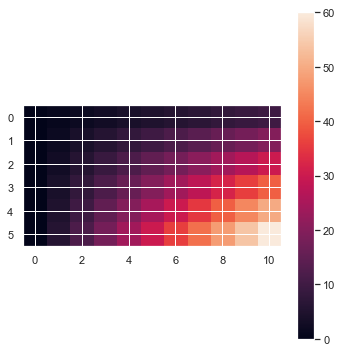

In [145]:
data2D = fakedata
burst = Burst
dip = Dip
plt.rcParams["figure.figsize"] = [5,5]
plt.rcParams["figure.autolayout"] = True
#plt.yticks(labels = DipName)
#plt.xticks(labels = BurstName)
im = plt.imshow(data2D)
plt.clim(np.min(data2D),np.max(data2D))
plt.colorbar(im)
plt.show()

In [74]:
np.array(data2D).shape

(2, 5)

In [ ]:
#NEED TO REMOVE AND recalcualte for burst 07/dip 06; all others should be good! 

5000


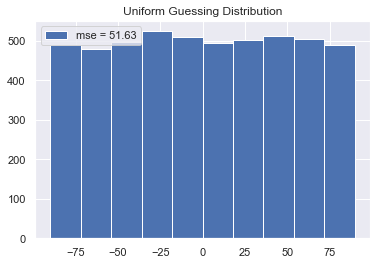

In [65]:
a = np.random.uniform(-90,90,5000)
print(len(a))
plt.hist(a)
mse = np.sqrt(np.mean(a**2))
legend = 'mse = {:.2f}'.format(mse)
plt.legend([legend])
plt.title('Uniform Guessing Distribution')
plt.show()

In [ ]:
#for comparison; uniform distribution - 


In [6]:
#memdataset for comparison to see error at 100. 
error = pd.read_csv("C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/memdataset.csv", header = None)

80
80


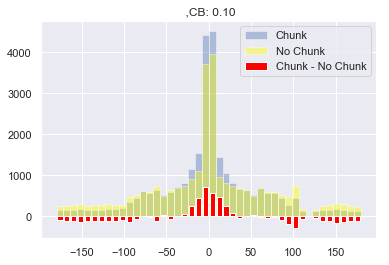

In [78]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
task = "4"
experiment = "decodedrew/contNoStimLoc/NoIgnore/Burst14/Dip11/Test90/"
errchunk, err, ax, diff, CB = overlayhist(base,base2,task,experiment)

<BarContainer object of 44 artists>

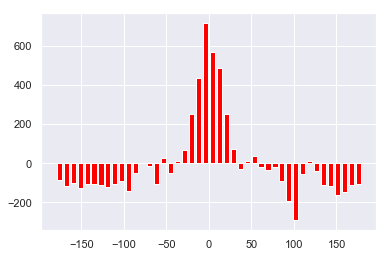

In [42]:
plt.bar(ax, diff,width = 6, color = "red" )

In [ ]:
Burst = [0.6,1.4]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
#BurstName = ["06", "14"]
DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
tests = ['Test45/','Test90/','']
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
task = "3"

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        for i in tests:
            test = i 
            experiment = expbase+gain + test
            print(experiment)
            name = "Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')
            errchunk, err = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png")
            #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        

In [ ]:
Burst = [0.5,1.5]
Dip = [0.5, 0.6, 0.7, 0.8,0.9,1.0,1.1,1.2, 1.3, 1.4, 1.5]
BurstName = ["05", "15"]
DipName = ["05", "06", "07", "08", "09", "1", "11", "12", "13","14", "15"]
tests = ['Test45/','Test90/','']
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
task = "4"

for burst in range(len(Burst)):
    for dip in range(len(Dip)):
        expbase = "decodedrew/contNoStimLoc/NoIgnore/"
        gain = "Burst"+BurstName[burst]+"/Dip"+DipName[dip]+"/"
        for i in tests:
            test = i 
            experiment = expbase+gain + test
            print(experiment)
            name = "Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')
            errchunk, err = overlayhist(base,base2,task,experiment, title = name, savefig = True, savefile = name+".png")
            #plt.savefig("Burst"+BurstName[burst]+"Dip"+DipName[dip]+"Test"+test.replace('/','')+".png")
        

80
80


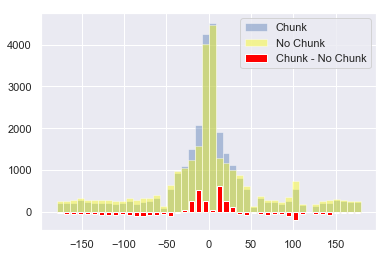

In [6]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Burst05/Dip05/Test45/"
task = "4"

errchunk, err = overlayhist(base,base2,task,experiment)


80
80


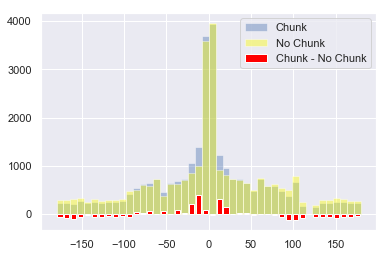

In [7]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Burst05/Dip05/Test90/"
task = "4"

errchunk, err = overlayhist(base,base2,task,experiment)


80
80


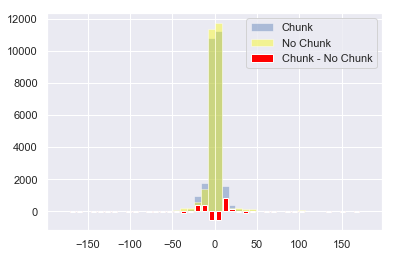

In [68]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Test45/"
task = "2"

errchunk, err = overlayhist(base,base2,task,experiment)
    

80
80


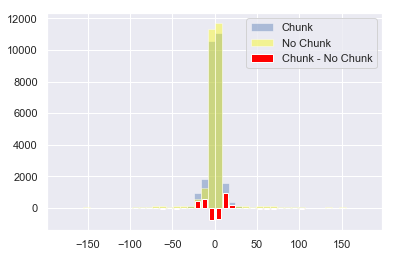

In [69]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/Test90/"
task = "2"

errchunk, err = overlayhist(base,base2,task,experiment)
    

80
80


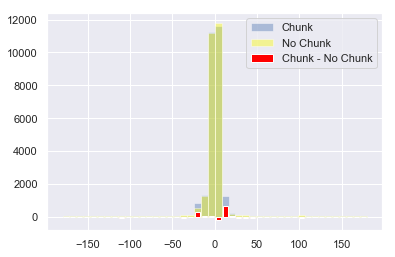

In [71]:
base = "Z:/leabra/examples/workingmemory/"
base2 = "results/Ring/2Stripe/"
experiment = "/decodedrew/contNoStimLoc/NoIgnore/"
task = "2"

errchunk, err = overlayhist(base,base2,task,experiment)
    

In [19]:

def overlayhist(base, base2, task,experiment, errchunk = [], err = [], title = '', savefig = False, savefile = ''):

    
    if len(errchunk) == 0:
        base_chunk = base+"sir"+task+"_chunk/"+base2+"hybrid/"+experiment
        files = os.listdir(base_chunk)
        files = [f for f in files if '.csv' in f]
        full_files = [base_chunk+f for f in files if 'EpcLog' not in f]
        full_files = [base+f for f in files if 'TrialLog' not in f]
        print(len(full_files))
        p = Precision()
        errchunk = p.mult_models(full_files)
    
    if len(err) == 0:
        if task == "2":
            base_nochunk = base + "sir2_new/"+base2+experiment
        else:
            base_nochunk = base+ "sir"+task+"/"+base2+experiment
        files = os.listdir(base_nochunk)
        files = [f for f in files if '.csv' in f]
        full_files = [base_nochunk+f for f in files if 'EpcLog' not in f]
        full_files = [base+f for f in files if 'TrialLog' not in f]
        print(len(full_files))
        p = Precision()
        err = p.mult_models(full_files)

    plot1 = plt.hist(errchunk,bins = np.linspace(-180,180,45), alpha = 0.4)
    plot2 = plt.hist(err,bins = np.linspace(-180,180,45), alpha = 0.4, color = "yellow")

    # calc middle of bin and width of bin
    ax = [(plot1[1][x]+plot1[1][x+1])/2 for x in range(len(plot1[1])-1)] 
    diff = [_plot1 - _plot2 for _plot1, _plot2 in zip(plot1[0], plot2[0])]
    plt.bar(ax, diff,width = 6, color = "red")
    plt.legend(['Chunk', "No Chunk", "Chunk - No Chunk"])
    plt.title(title)
    if savefig: 
        plt.savefig(savefile)    
    plt.show()
    
    return errchunk, err



(array([ 7.,  2.,  6.,  4.,  2.,  9.,  4.,  8.,  4.,  5.,  3.,  6.,  7.,
         5.,  3.,  3.,  5.,  1.,  4.,  6.,  5.,  4.,  4.,  8., 21., 18.,
        15.,  6.,  3.,  5.,  5.,  1.,  0.,  7., 10.,  7.,  5.,  5.,  7.,
         6.,  4.,  1.,  1.,  6.,  8.,  4.,  8.,  3.,  4.,  6.]),
 array([-179.7    , -172.55976, -165.41952, -158.27928, -151.13904,
        -143.9988 , -136.85856, -129.71832, -122.57808, -115.43784,
        -108.2976 , -101.15736,  -94.01712,  -86.87688,  -79.73664,
         -72.5964 ,  -65.45616,  -58.31592,  -51.17568,  -44.03544,
         -36.8952 ,  -29.75496,  -22.61472,  -15.47448,   -8.33424,
          -1.194  ,    5.94624,   13.08648,   20.22672,   27.36696,
          34.5072 ,   41.64744,   48.78768,   55.92792,   63.06816,
          70.2084 ,   77.34864,   84.48888,   91.62912,   98.76936,
         105.9096 ,  113.04984,  120.19008,  127.33032,  134.47056,
         141.6108 ,  148.75104,  155.89128,  163.03152,  170.17176,
         177.312  ]),
 <a list of 50

C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\figure.py:2366: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


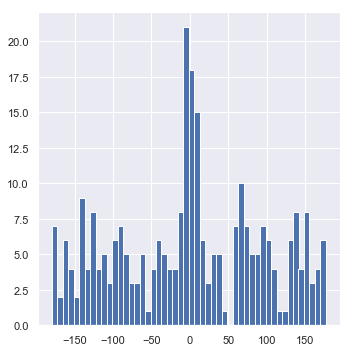

In [277]:
files = ["C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir4_chunk/results/trainedparam.csv"]
p = Precision()
err = p.mult_models(files, ',')

#print(len(err))
plt.figure()
plt.hist(err, bins = 50)

(array([24., 14., 14., 15., 25., 16., 16., 18., 17., 15.,  9., 11., 19.,
        17., 14., 23., 13., 22., 21., 12., 15., 21., 12., 16., 26., 22.,
        25., 12., 23.,  8.,  9., 17., 20.,  2., 14., 19., 22., 13., 21.,
        10., 13., 17., 22., 16., 15., 19., 27., 10., 12., 18.]),
 array([-179.5  , -172.312, -165.124, -157.936, -150.748, -143.56 ,
        -136.372, -129.184, -121.996, -114.808, -107.62 , -100.432,
         -93.244,  -86.056,  -78.868,  -71.68 ,  -64.492,  -57.304,
         -50.116,  -42.928,  -35.74 ,  -28.552,  -21.364,  -14.176,
          -6.988,    0.2  ,    7.388,   14.576,   21.764,   28.952,
          36.14 ,   43.328,   50.516,   57.704,   64.892,   72.08 ,
          79.268,   86.456,   93.644,  100.832,  108.02 ,  115.208,
         122.396,  129.584,  136.772,  143.96 ,  151.148,  158.336,
         165.524,  172.712,  179.9  ]),
 <a list of 50 Patch objects>)

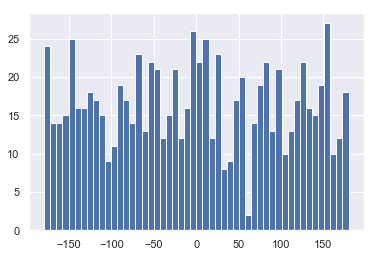

In [79]:
files = ["C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir4_chunk/results/untrained.csv","C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir4_chunk/results/untrained2.csv","C:/Users/Aneri/go/src/leabra/examples/sir_proj/sir4_chunk/results/untrained3.csv"]
p = Precision()
err = p.mult_models(files, ',')

#print(len(err))
plt.figure()
plt.hist(err, bins = 50)

80


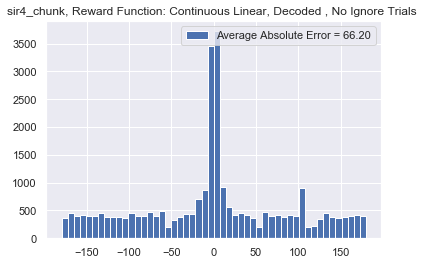

80


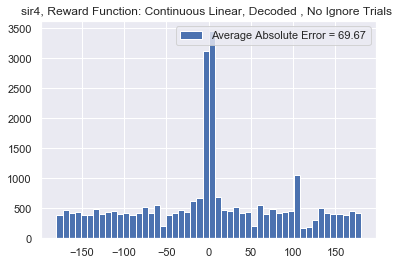

In [6]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/")

80


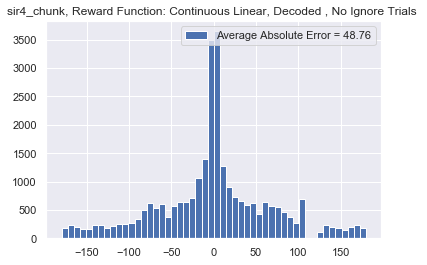

80


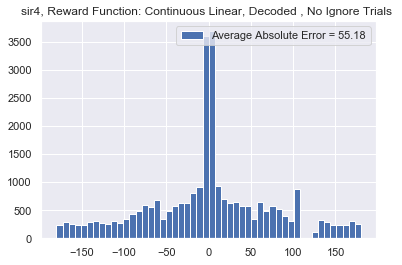

In [9]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/Test90/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/Test90/")

80


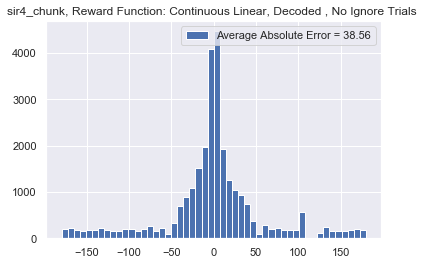

80


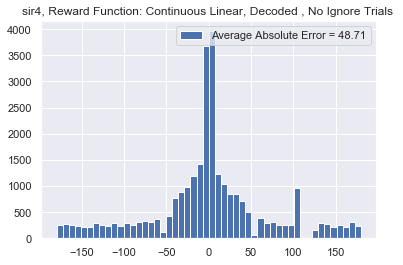

In [10]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/Test45/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/Test45/")

80


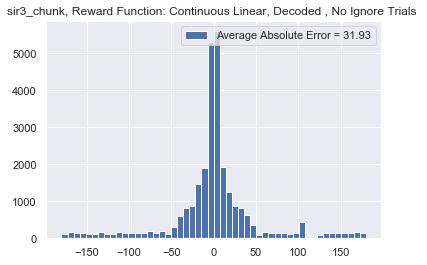

80


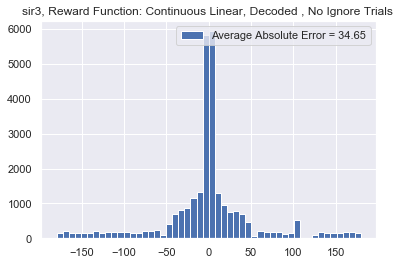

80


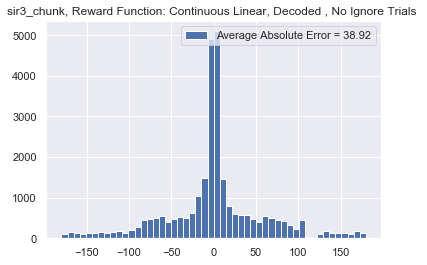

80


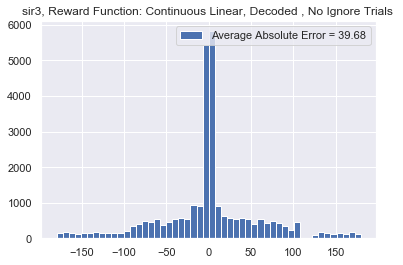

In [11]:
modelerr("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/Test45/")
modelerr("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/Test45/")
modelerr("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/Test90/")
modelerr("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/Test90/")

80


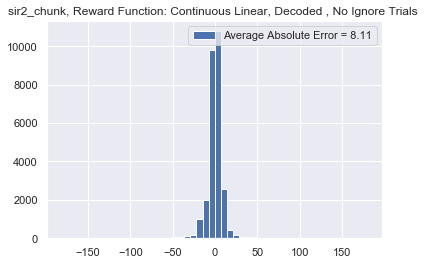

80


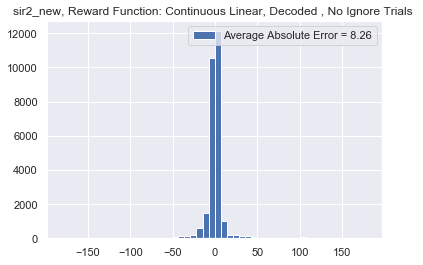

80


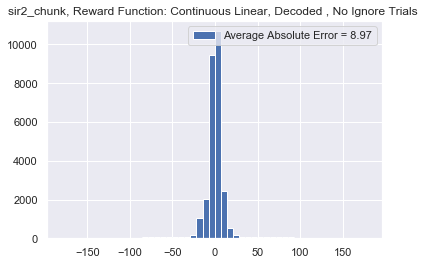

80


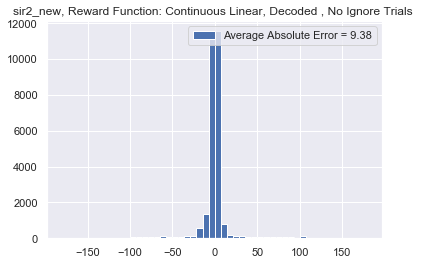

In [13]:
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/Test45/")
modelerr("Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/Test45/")
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/Test90/")
modelerr("Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/Test90/")

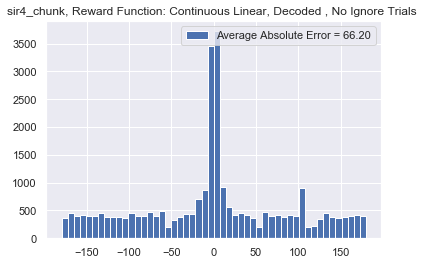

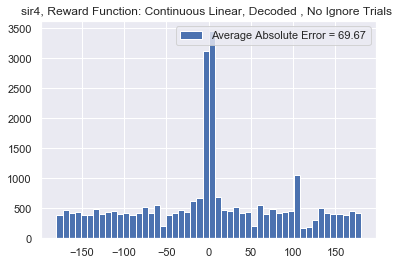

In [3]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/")

80


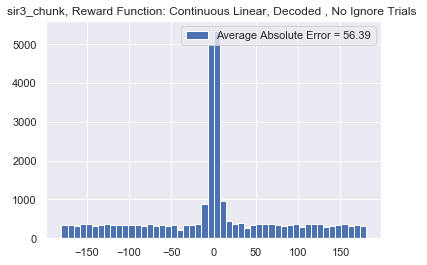

80


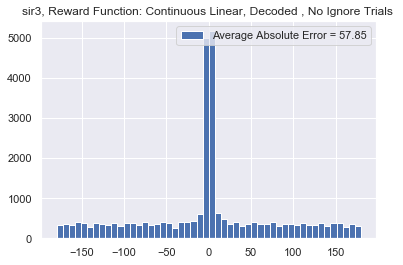

80


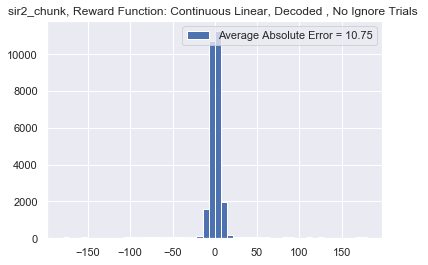

80


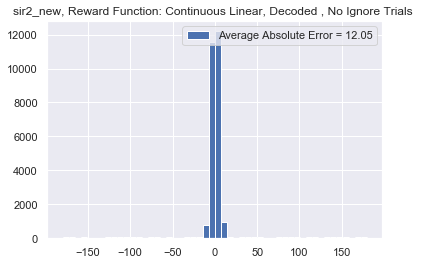

In [29]:
modelerr("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma12/")
modelerr("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma12/")
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma12/")
modelerr("Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma12/")

80


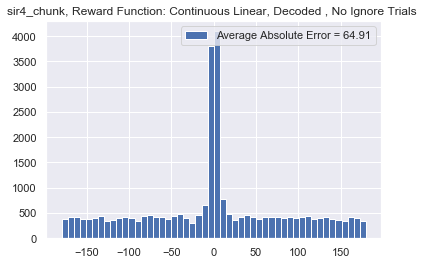

80


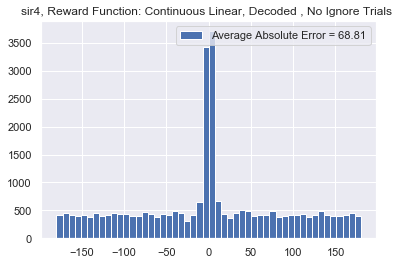

In [28]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma08/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma08/")

80


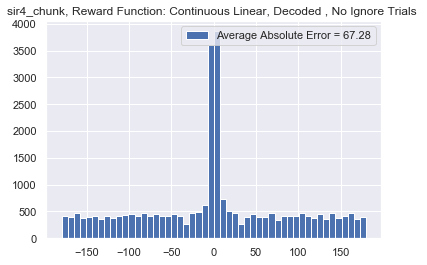

80


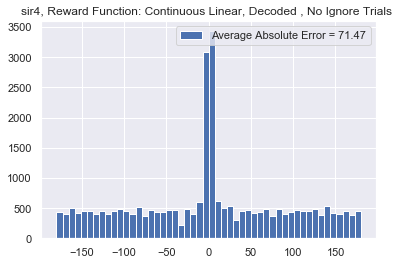

In [27]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma1/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma1/")

80


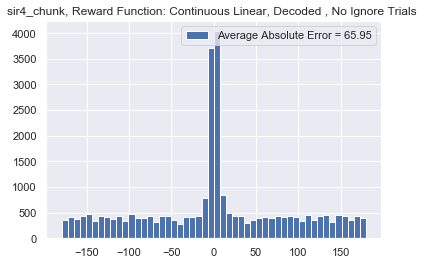

80


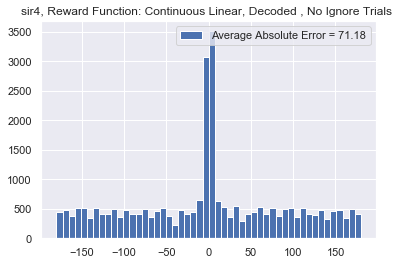

In [23]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma12/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma12/")

80


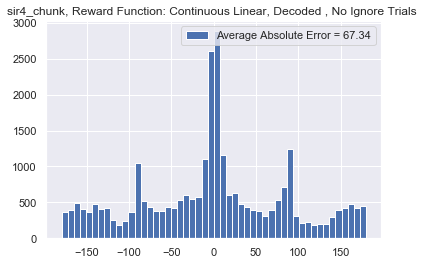

80


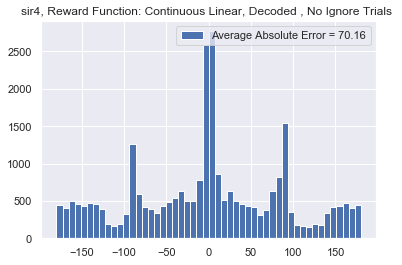

In [24]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma18/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma18/")

80


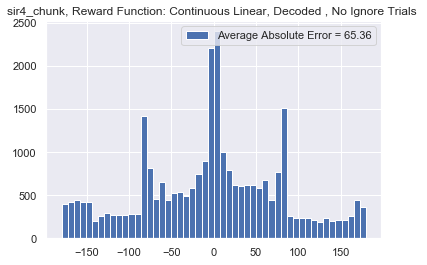

80


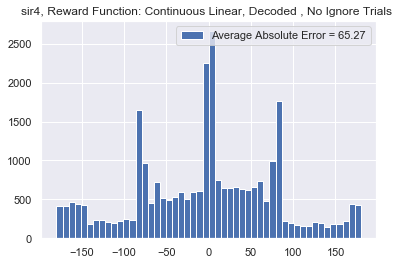

In [25]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma2/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma2/")

80


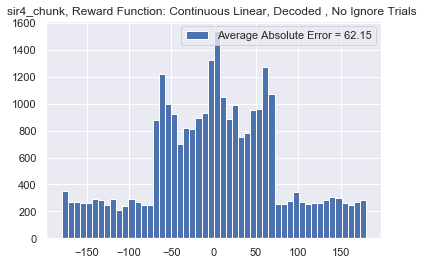

80


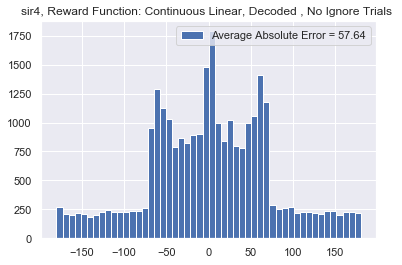

In [26]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/sigma25/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/sigma25/")

80


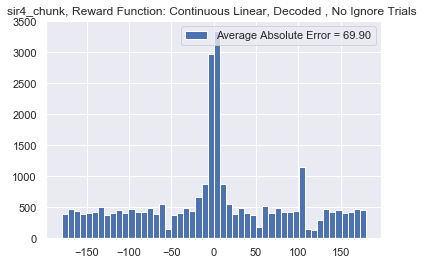

80


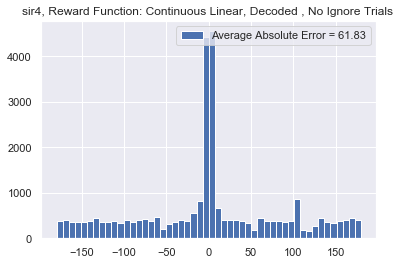

In [18]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/pretrain2/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/pretrain2/")

80


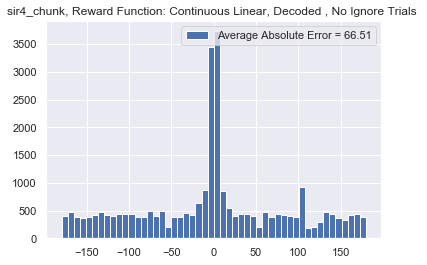

80


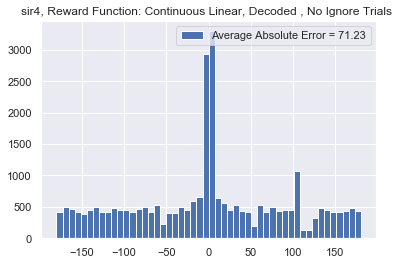

In [19]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/pretrain3/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/pretrain3/")

80


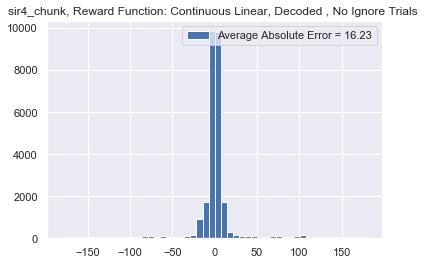

80


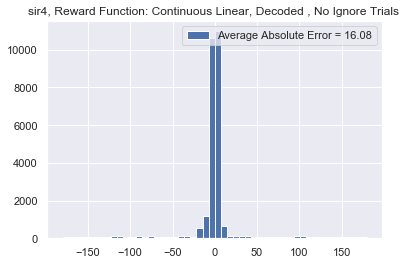

In [13]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/mimic2/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/mimic2/")

80


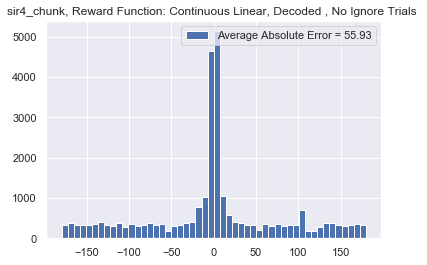

80


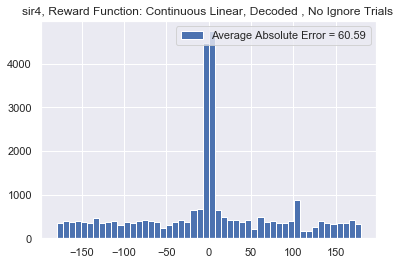

In [14]:
modelerr("Z:/leabra/examples/workingmemory/sir4_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/mimic3/")
modelerr("Z:/leabra/examples/workingmemory/sir4/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/mimic3/")

80


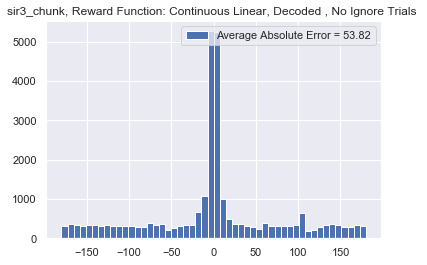

80


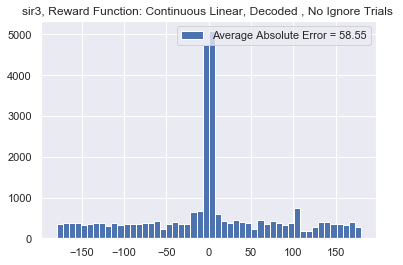

In [15]:
modelerr("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/")
modelerr("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/")

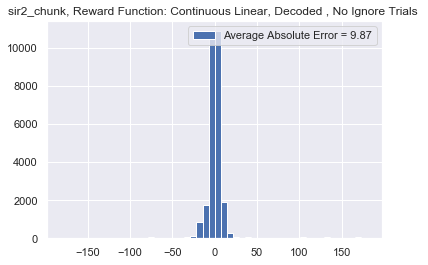

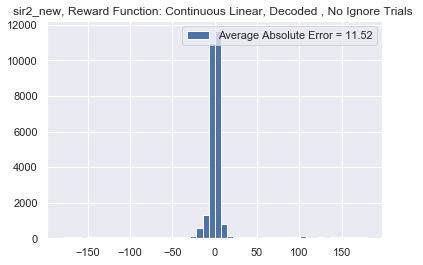

In [10]:
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/NoIgnore/")
modelerr("Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/NoIgnore/")

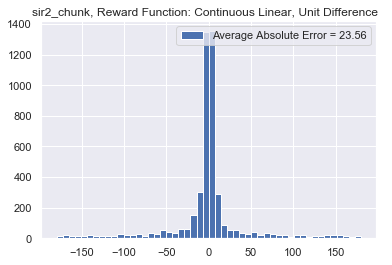

In [7]:
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/cont/")

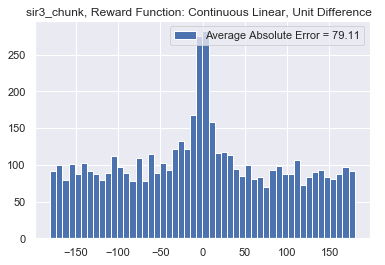

In [8]:
modelerr("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/cont/")

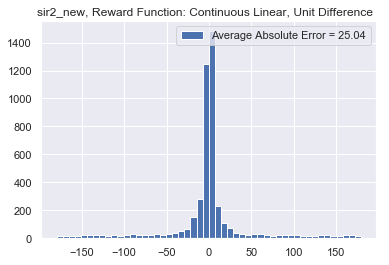

In [9]:
modelerr("Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/cont/")

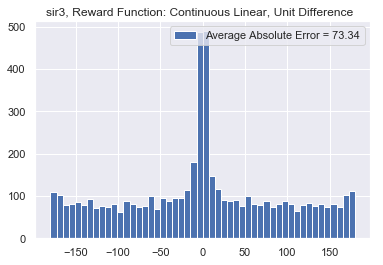

In [10]:
modelerr("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/cont/")

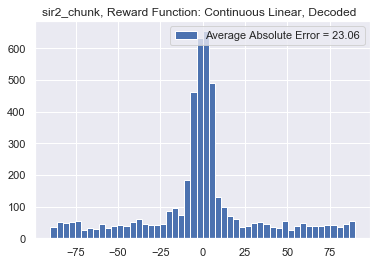

In [72]:
modelerr("Z:/leabra/examples/workingmemory/sir2_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/")

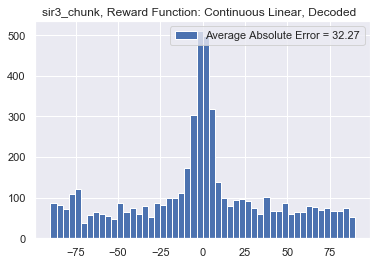

In [73]:
modelerr("Z:/leabra/examples/workingmemory/sir3_chunk/results/Ring/2Stripe/hybrid/decodedrew/contNoStimLoc/")

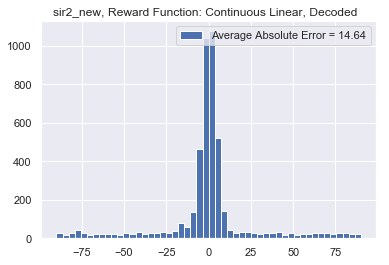

In [74]:
modelerr("Z:/leabra/examples/workingmemory/sir2_new/results/Ring/2Stripe/decodedrew/contNoStimLoc/")

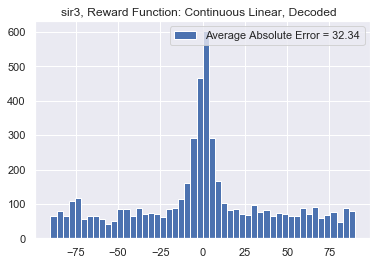

In [75]:
modelerr("Z:/leabra/examples/workingmemory/sir3/results/Ring/2Stripe/decodedrew/contNoStimLoc/")